In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
import yfinance as yf

ticker = "RELIANCE.NS"

data = yf.download(
    ticker,
    start="2015-01-01",
    auto_adjust=False,
    progress=True
)

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price        Adj Close       Close        High         Low        Open  \
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS   
Date                                                                     
2015-01-01  189.125366  202.959000  203.896194  201.987518  202.593277   
2015-01-02  188.624817  202.421829  204.821960  202.136108  203.004715   
2015-01-05  186.558685  200.204575  203.644760  199.804550  202.296112   
2015-01-06  178.091827  191.118393  199.553116  190.181198  198.867371   
2015-01-07  181.968491  195.278610  196.307236  191.324127  191.346985   

Price           Volume  
Ticker     RELIANCE.NS  
Date                    
2015-01-01     2963643  
2015-01-02     7331366  
2015-01-05    10103941  
2015-01-06    18627980  
2015-01-07    20720312  


In [3]:
print("Rows:", len(data))
print("Columns:", data.columns)
print("\nLatest rows:")
print(data.tail())

Rows: 2905
Columns: MultiIndex([('Adj Close', 'RELIANCE.NS'),
            (    'Close', 'RELIANCE.NS'),
            (     'High', 'RELIANCE.NS'),
            (      'Low', 'RELIANCE.NS'),
            (     'Open', 'RELIANCE.NS'),
            (   'Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

Latest rows:
Price         Adj Close        Close         High          Low         Open  \
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
Date                                                                          
2026-09-24  1219.199951  1219.199951  1241.599976  1219.199951  1236.599976   
2026-09-25  1226.000000  1226.000000  1227.400024  1210.500000  1210.500000   
2026-09-28  1197.599976  1197.599976  1219.699951  1197.000000  1218.000000   
2026-09-29  1182.000000  1182.000000  1198.300049  1181.800049  1193.800049   
2026-09-30  1189.800049  1189.800049  1196.500000  1181.699951  1182.000000   

Price           Volume  
Ticker     RELIAN

In [4]:
data.columns = data.columns.get_level_values(0)

print(data.head())
print("\nColumns:")
print(data.columns)

Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-01-01  189.125366  202.959000  203.896194  201.987518  202.593277   
2015-01-02  188.624817  202.421829  204.821960  202.136108  203.004715   
2015-01-05  186.558685  200.204575  203.644760  199.804550  202.296112   
2015-01-06  178.091827  191.118393  199.553116  190.181198  198.867371   
2015-01-07  181.968491  195.278610  196.307236  191.324127  191.346985   

Price         Volume  
Date                  
2015-01-01   2963643  
2015-01-02   7331366  
2015-01-05  10103941  
2015-01-06  18627980  
2015-01-07  20720312  

Columns:
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [5]:
print("Missing values:")
print(data.isnull().sum())

print("\nDuplicate dates:")
print(data.index.duplicated().sum())

Missing values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate dates:
0


In [6]:
from pathlib import Path

Path("data").mkdir(exist_ok=True)

data.to_csv("data/reliance_raw.csv")

print("Saved successfully.")

Saved successfully.


In [7]:
from pathlib import Path

file_path = Path("data/reliance_raw.csv")

print(file_path.exists())
print(file_path)


True
data\reliance_raw.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
data = pd.read_csv(
    "data/reliance_raw.csv",
    index_col="Date",
    parse_dates=True
)

print(data.head())

             Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-01-01  189.125366  202.959000  203.896194  201.987518  202.593277   
2015-01-02  188.624817  202.421829  204.821960  202.136108  203.004715   
2015-01-05  186.558685  200.204575  203.644760  199.804550  202.296112   
2015-01-06  178.091827  191.118393  199.553116  190.181198  198.867371   
2015-01-07  181.968491  195.278610  196.307236  191.324127  191.346985   

              Volume  
Date                  
2015-01-01   2963643  
2015-01-02   7331366  
2015-01-05  10103941  
2015-01-06  18627980  
2015-01-07  20720312  


In [10]:
print("Shape:", data.shape)

print("\nColumns:")
print(data.columns)

Shape: (2905, 6)

Columns:
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [11]:
print(data.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2905 entries, 2015-01-01 to 2026-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  2905 non-null   float64
 1   Close      2905 non-null   float64
 2   High       2905 non-null   float64
 3   Low        2905 non-null   float64
 4   Open       2905 non-null   float64
 5   Volume     2905 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 158.9 KB
None


In [12]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [13]:
print("Duplicate dates:", data.index.duplicated().sum())

Duplicate dates: 0


In [14]:
data.describe()

,Adj Close,Close,High,Low,Open,Volume
count,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2.905000e+03
mean,823.277083,838.200270,846.920022,830.154682,838.722597,1.756756e+07
std,448.980265,448.933472,452.730780,445.439376,449.172514,1.288881e+07
min,172.692184,185.323807,186.912460,182.055069,186.661026,0.000000e+00
25%,400.916718,416.844269,421.461670,413.049805,417.621460,1.021447e+07
50%,900.274170,920.530640,931.306702,913.838928,922.284363,1.405367e+07
75%,1217.394043,1229.966309,1241.599976,1220.828613,1230.000000,2.024805e+07
max,1584.971802,1600.900024,1611.800049,1585.500000,1604.449951,1.426834e+08


In [15]:
data["Daily_Return"] = data["Close"].pct_change()

print(data[["Close", "Daily_Return"]].head(10))

                 Close  Daily_Return
Date                                
2015-01-01  202.959000           NaN
2015-01-02  202.421829     -0.002647
2015-01-05  200.204575     -0.010954
2015-01-06  191.118393     -0.045384
2015-01-07  195.278610      0.021768
2015-01-08  192.478470     -0.014339
2015-01-09  196.650101      0.021673
2015-01-12  194.364273     -0.011624
2015-01-13  192.729904     -0.008409
2015-01-14  190.855530     -0.009725


In [16]:
print(data["Daily_Return"].describe())

count    2904.000000
mean        0.000752
std         0.016905
min        -0.131539
25%        -0.008584
50%         0.000533
75%         0.009376
max         0.147180
Name: Daily_Return, dtype: float64


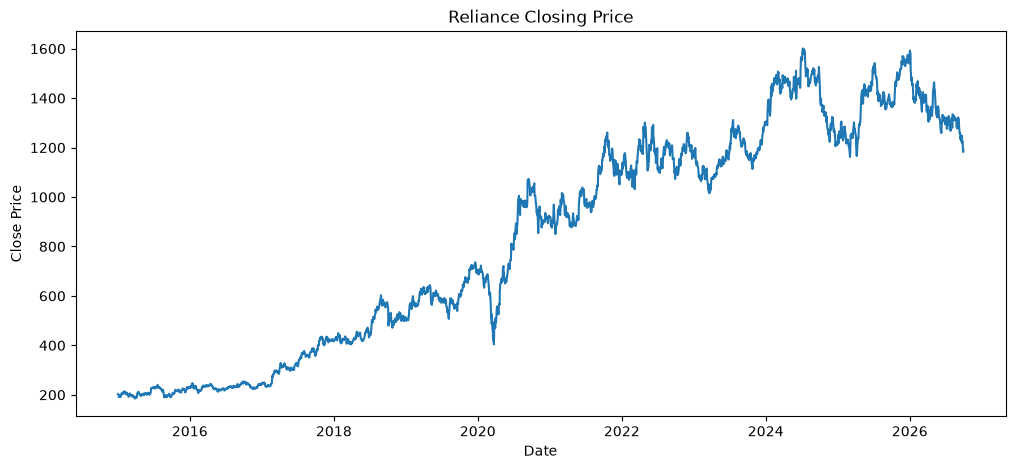

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Close"])

plt.title("Reliance Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

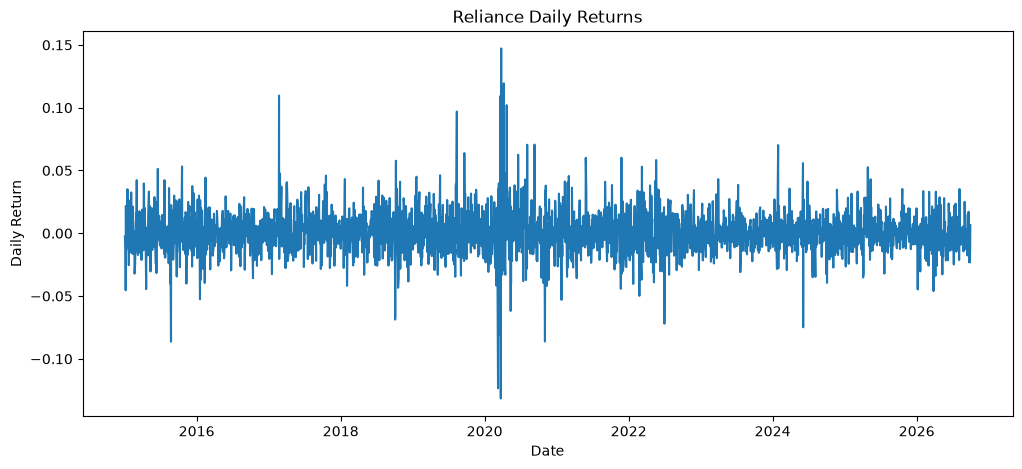

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Daily_Return"])

plt.title("Reliance Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

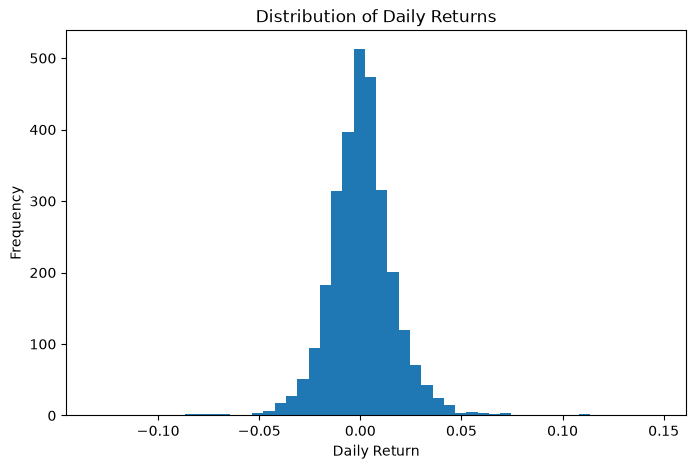

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["Daily_Return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

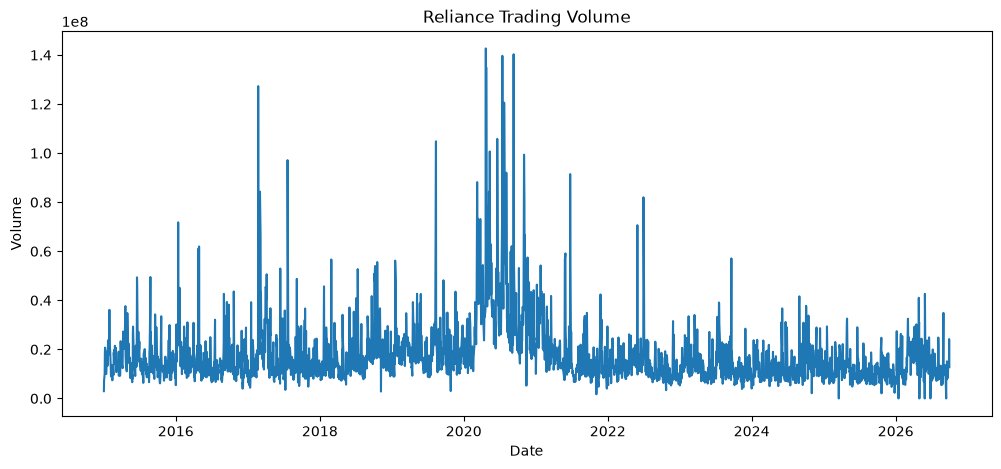

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Volume"])

plt.title("Reliance Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [21]:
correlation = data.corr(numeric_only=True)

print(correlation)

              Adj Close     Close      High       Low      Open    Volume  \
Adj Close      1.000000  0.999941  0.999760  0.999799  0.999538 -0.142628   
Close          0.999941  1.000000  0.999839  0.999829  0.999591 -0.140613   
High           0.999760  0.999839  1.000000  0.999755  0.999812 -0.134724   
Low            0.999799  0.999829  0.999755  1.000000  0.999795 -0.147386   
Open           0.999538  0.999591  0.999812  0.999795  1.000000 -0.141644   
Volume        -0.142628 -0.140613 -0.134724 -0.147386 -0.141644  1.000000   
Daily_Return  -0.010944 -0.010440 -0.020610 -0.021156 -0.032305  0.127112   

              Daily_Return  
Adj Close        -0.010944  
Close            -0.010440  
High             -0.020610  
Low              -0.021156  
Open             -0.032305  
Volume            0.127112  
Daily_Return      1.000000  


In [22]:
data = data.dropna()

print("Final shape:", data.shape)

Final shape: (2904, 7)


In [23]:
data.to_csv("data/reliance_clean.csv")

print("Cleaned data saved successfully.")

Cleaned data saved successfully.


In [24]:
import pandas as pd
import numpy as np

data = pd.read_csv(
    "data/reliance_clean.csv",
    index_col="Date",
    parse_dates=True
)

print(data.head())
print(data.shape)

             Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-01-02  188.624817  202.421829  204.821960  202.136108  203.004715   
2015-01-05  186.558685  200.204575  203.644760  199.804550  202.296112   
2015-01-06  178.091827  191.118393  199.553116  190.181198  198.867371   
2015-01-07  181.968491  195.278610  196.307236  191.324127  191.346985   
2015-01-08  179.359192  192.478470  197.244431  192.044159  196.604385   

              Volume  Daily_Return  
Date                                
2015-01-02   7331366     -0.002647  
2015-01-05  10103941     -0.010954  
2015-01-06  18627980     -0.045384  
2015-01-07  20720312      0.021768  
2015-01-08  19872227     -0.014339  
(2904, 7)


In [25]:
data["Return_Lag_1"] = data["Daily_Return"].shift(1)
data["Return_Lag_2"] = data["Daily_Return"].shift(2)
data["Return_Lag_3"] = data["Daily_Return"].shift(3)
data["Return_Lag_5"] = data["Daily_Return"].shift(5)

print(data[[
    "Daily_Return",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5"
]].head(10))

            Daily_Return  Return_Lag_1  Return_Lag_2  Return_Lag_3  \
Date                                                                 
2015-01-02     -0.002647           NaN           NaN           NaN   
2015-01-05     -0.010954     -0.002647           NaN           NaN   
2015-01-06     -0.045384     -0.010954     -0.002647           NaN   
2015-01-07      0.021768     -0.045384     -0.010954     -0.002647   
2015-01-08     -0.014339      0.021768     -0.045384     -0.010954   
2015-01-09      0.021673     -0.014339      0.021768     -0.045384   
2015-01-12     -0.011624      0.021673     -0.014339      0.021768   
2015-01-13     -0.008409     -0.011624      0.021673     -0.014339   
2015-01-14     -0.009725     -0.008409     -0.011624      0.021673   
2015-01-15      0.035092     -0.009725     -0.008409     -0.011624   

            Return_Lag_5  
Date                      
2015-01-02           NaN  
2015-01-05           NaN  
2015-01-06           NaN  
2015-01-07           NaN

In [26]:
data["Return_5D"] = data["Close"].pct_change(5)
data["Return_10D"] = data["Close"].pct_change(10)
data["Return_20D"] = data["Close"].pct_change(20)

In [27]:
data["SMA_5"] = data["Close"].rolling(5).mean()
data["SMA_10"] = data["Close"].rolling(10).mean()
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()

In [28]:
data["Close_SMA5_Ratio"] = data["Close"] / data["SMA_5"]
data["Close_SMA10_Ratio"] = data["Close"] / data["SMA_10"]
data["Close_SMA20_Ratio"] = data["Close"] / data["SMA_20"]

In [29]:
data["EMA_12"] = data["Close"].ewm(span=12, adjust=False).mean()
data["EMA_26"] = data["Close"].ewm(span=26, adjust=False).mean()

In [30]:
data["MACD"] = data["EMA_12"] - data["EMA_26"]

data["MACD_Signal"] = data["MACD"].ewm(
    span=9,
    adjust=False
).mean()

data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

In [31]:
def calculate_rsi(series, period=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

In [32]:
data["RSI_14"] = calculate_rsi(data["Close"], 14)

In [33]:
data["Volatility_5"] = data["Daily_Return"].rolling(5).std()
data["Volatility_10"] = data["Daily_Return"].rolling(10).std()
data["Volatility_20"] = data["Daily_Return"].rolling(20).std()

In [34]:
data["High_Low_Range"] = (
    (data["High"] - data["Low"]) / data["Close"]
)

data["Open_Close_Change"] = (
    (data["Close"] - data["Open"]) / data["Open"]
)

In [35]:
data["Volume_Change"] = data["Volume"].pct_change()

data["Volume_MA_5"] = data["Volume"].rolling(5).mean()
data["Volume_MA_20"] = data["Volume"].rolling(20).mean()

data["Volume_Ratio_5"] = (
    data["Volume"] / data["Volume_MA_5"]
)

In [36]:
data["Next_Day_Return"] = (
    data["Close"].shift(-1) / data["Close"] - 1
)

In [ ]:
print(data["Target"].value_counts())

print("\nPercentage:")
print(data["Target"].value_counts(normalize=True) * 100)

In [38]:
data["Target"] = (
    data["Next_Day_Return"] > 0
).astype(int)

In [39]:
print(data["Target"].value_counts())

print("\nPercentage:")
print(data["Target"].value_counts(normalize=True) * 100)

Target
1    1496
0    1408
Name: count, dtype: int64

Percentage:
Target
1    51.515152
0    48.484848
Name: proportion, dtype: float64


In [40]:
data = data.dropna().copy()

print("Final shape:", data.shape)

Final shape: (2854, 38)


In [41]:
feature_columns = [
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",

    "Return_5D",
    "Return_10D",
    "Return_20D",

    "Close_SMA5_Ratio",
    "Close_SMA10_Ratio",
    "Close_SMA20_Ratio",

    "EMA_12",
    "EMA_26",

    "MACD",
    "MACD_Signal",
    "MACD_Hist",

    "RSI_14",

    "Volatility_5",
    "Volatility_10",
    "Volatility_20",

    "High_Low_Range",
    "Open_Close_Change",

    "Volume_Change",
    "Volume_Ratio_5"
]

In [42]:
X = data[feature_columns]
y = data["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2854, 23)
y shape: (2854,)


In [43]:
print("Missing values in X:")
print(X.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X.to_numpy()).sum())

Missing values in X:
0

Infinite values:
6


In [44]:
data.to_csv("data/reliance_features.csv")

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


In [45]:
import pandas as pd
import numpy as np

data = pd.read_csv(
    "data/reliance_features.csv",
    index_col="Date",
    parse_dates=True
)

print(data.head())
print("\nShape:", data.shape)

             Adj Close       Close        High         Low        Open  \
Date                                                                     
2015-03-17  182.511612  195.861496  196.558670  192.238449  194.421417   
2015-03-18  185.025070  198.558777  199.381683  195.370041  195.895782   
2015-03-19  182.362503  195.701492  200.398865  195.232895  200.136002   
2015-03-20  181.925873  195.232895  196.844406  193.975677  196.101501   
2015-03-23  179.337891  192.455612  197.495865  191.575562  195.781494   

              Volume  Daily_Return  Return_Lag_1  Return_Lag_2  Return_Lag_3  \
Date                                                                           
2015-03-17  19070082      0.017516     -0.009411     -0.015860      0.009171   
2015-03-18   9269885      0.013771      0.017516     -0.009411     -0.015860   
2015-03-19  13934612     -0.014390      0.013771      0.017516     -0.009411   
2015-03-20  10405717     -0.002394     -0.014390      0.013771      0.017516   
2

In [46]:
data = data.sort_index()

print("First date:", data.index.min())
print("Last date:", data.index.max())

First date: 2015-03-17 00:00:00
Last date: 2026-09-29 00:00:00


In [47]:
feature_columns = [
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",

    "Return_5D",
    "Return_10D",
    "Return_20D",

    "Close_SMA5_Ratio",
    "Close_SMA10_Ratio",
    "Close_SMA20_Ratio",

    "EMA_12",
    "EMA_26",

    "MACD",
    "MACD_Signal",
    "MACD_Hist",

    "RSI_14",

    "Volatility_5",
    "Volatility_10",
    "Volatility_20",

    "High_Low_Range",
    "Open_Close_Change",

    "Volume_Change",
    "Volume_Ratio_5"
]

In [48]:
X = data[feature_columns]
y = data["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2854, 23)
y shape: (2854,)


In [49]:
n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

print("Total samples:", n)
print("Train end:", train_end)
print("Validation end:", val_end)

Total samples: 2854
Train end: 1997
Validation end: 2425


In [50]:
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [51]:
print("Training:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_val.shape, y_val.shape)

print("\nTesting:")
print(X_test.shape, y_test.shape)

Training:
(1997, 23) (1997,)

Validation:
(428, 23) (428,)

Testing:
(429, 23) (429,)


In [52]:
print("TRAIN")
print(X_train.index.min(), "to", X_train.index.max())

print("\nVALIDATION")
print(X_val.index.min(), "to", X_val.index.max())

print("\nTEST")
print(X_test.index.min(), "to", X_test.index.max())

TRAIN
2015-03-17 00:00:00 to 2023-04-18 00:00:00

VALIDATION
2023-04-19 00:00:00 to 2025-01-10 00:00:00

TEST
2025-01-13 00:00:00 to 2026-09-29 00:00:00


In [53]:
def show_balance(name, labels):
    print(f"\n{name}")
    print(labels.value_counts())
    print((labels.value_counts(normalize=True) * 100).round(2))

show_balance("TRAIN", y_train)
show_balance("VALIDATION", y_val)
show_balance("TEST", y_test)


TRAIN
Target
1    1039
0     958
Name: count, dtype: int64
Target
1    52.03
0    47.97
Name: proportion, dtype: float64

VALIDATION
Target
1    226
0    202
Name: count, dtype: int64
Target
1    52.8
0    47.2
Name: proportion, dtype: float64

TEST
Target
0    220
1    209
Name: count, dtype: int64
Target
0    51.28
1    48.72
Name: proportion, dtype: float64


In [54]:
for name, X_part in [
    ("Train", X_train),
    ("Validation", X_val),
    ("Test", X_test)
]:
    print(
        name,
        "NaN =", X_part.isnull().sum().sum(),
        "Inf =", np.isinf(X_part.to_numpy()).sum()
    )

Train NaN = 0 Inf = 0
Validation NaN = 0 Inf = 0
Test NaN = 0 Inf = 6


In [55]:
from pathlib import Path

Path("data/splits").mkdir(
    parents=True,
    exist_ok=True
)

In [56]:
X_train.to_csv("data/splits/X_train.csv")
y_train.to_csv("data/splits/y_train.csv")

X_val.to_csv("data/splits/X_val.csv")
y_val.to_csv("data/splits/y_val.csv")

X_test.to_csv("data/splits/X_test.csv")
y_test.to_csv("data/splits/y_test.csv")

print("All splits saved successfully.")

All splits saved successfully.


In [57]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [58]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1997, 23)
y_train: (1997,)
X_val: (428, 23)
y_val: (428,)


In [59]:
print("Training period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nValidation period:")
print(X_val.index.min(), "to", X_val.index.max())

Training period:
2015-03-17 00:00:00 to 2023-04-18 00:00:00

Validation period:
2023-04-19 00:00:00 to 2025-01-10 00:00:00


In [60]:
print("Training target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

Training target:
Target
1    1039
0     958
Name: count, dtype: int64

Validation target:
Target
1    226
0    202
Name: count, dtype: int64


In [61]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [62]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1997, 23)
y_train: (1997,)
X_val: (428, 23)
y_val: (428,)


In [63]:
print("Training period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nValidation period:")
print(X_val.index.min(), "to", X_val.index.max())

Training period:
2015-03-17 00:00:00 to 2023-04-18 00:00:00

Validation period:
2023-04-19 00:00:00 to 2025-01-10 00:00:00


In [64]:
print("Training target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

Training target:
Target
1    1039
0     958
Name: count, dtype: int64

Validation target:
Target
1    226
0    202
Name: count, dtype: int64


In [66]:
model = Pipeline([
    ("scaler", StandardScaler()),

    ("logistic", LogisticRegression(
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(max_iter=2000, random_state=42))])


In [67]:
model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [68]:
val_pred = model.predict(X_val)

val_prob = model.predict_proba(X_val)[:, 1]

print("First 10 predictions:")
print(val_pred[:10])

print("\nFirst 10 UP probabilities:")
print(val_prob[:10])

First 10 predictions:
[1 1 1 1 1 1 1 1 1 1]

First 10 UP probabilities:
[0.55956202 0.55811521 0.56829241 0.55505336 0.54352889 0.52596213
 0.53404839 0.53568743 0.55503045 0.52995251]


In [69]:
accuracy = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred, zero_division=0)
recall = recall_score(y_val, val_pred, zero_division=0)
f1 = f1_score(y_val, val_pred, zero_division=0)
roc_auc = roc_auc_score(y_val, val_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.4977
Precision : 0.5223
Recall    : 0.5708
F1 Score  : 0.5455
ROC-AUC   : 0.4622


In [70]:
cm = confusion_matrix(y_val, val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 84 118]
 [ 97 129]]


In [71]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.46      0.42      0.44       202
          UP       0.52      0.57      0.55       226

    accuracy                           0.50       428
   macro avg       0.49      0.49      0.49       428
weighted avg       0.49      0.50      0.50       428



In [72]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:

    temp_model = Pipeline([
        ("scaler", StandardScaler()),

        ("logistic", LogisticRegression(
            C=C,
            max_iter=2000,
            random_state=42
        ))
    ])

    temp_model.fit(X_train, y_train)

    pred = temp_model.predict(X_val)
    prob = temp_model.predict_proba(X_val)[:, 1]

    results.append({
        "C": C,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

results_df

,C,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.001,0.518692,0.525126,0.924779,0.669872,0.476036
1,0.010,0.507009,0.527273,0.641593,0.578842,0.465653
2,0.100,0.509346,0.531496,0.597345,0.562500,0.463266
3,1.000,0.497664,0.522267,0.570796,0.545455,0.462214
4,10.000,0.495327,0.520161,0.570796,0.544304,0.462105
5,100.000,0.495327,0.520161,0.570796,0.544304,0.462017


In [73]:
best_row = results_df.loc[
    results_df["ROC_AUC"].idxmax()
]

best_C = best_row["C"]

print("Best C:", best_C)
print("\nBest validation results:")
print(best_row)

Best C: 0.001

Best validation results:
C            0.001000
Accuracy     0.518692
Precision    0.525126
Recall       0.924779
F1           0.669872
ROC_AUC      0.476036
Name: 0, dtype: float64


In [74]:
best_model = Pipeline([
    ("scaler", StandardScaler()),

    ("logistic", LogisticRegression(
        C=best_C,
        max_iter=2000,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

print("Best Logistic Regression model trained.")

Best Logistic Regression model trained.


In [75]:
val_pred = best_model.predict(X_val)
val_prob = best_model.predict_proba(X_val)[:, 1]

print("Accuracy:",
      round(accuracy_score(y_val, val_pred), 4))

print("Precision:",
      round(precision_score(y_val, val_pred, zero_division=0), 4))

print("Recall:",
      round(recall_score(y_val, val_pred, zero_division=0), 4))

print("F1:",
      round(f1_score(y_val, val_pred, zero_division=0), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_val, val_prob), 4))

Accuracy: 0.5187
Precision: 0.5251
Recall: 0.9248
F1: 0.6699
ROC-AUC: 0.476


In [76]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

validation_results = pd.DataFrame({
    "Actual": y_val,
    "Predicted": val_pred,
    "Prob_UP": val_prob
})

validation_results.to_csv(
    "results/logistic_validation_predictions.csv"
)

print("Validation predictions saved.")

Validation predictions saved.


In [77]:
results_df.to_csv(
    "results/logistic_tuning_results.csv",
    index=False
)

print("Tuning results saved.")

Tuning results saved.


In [78]:
import joblib

In [79]:
Path("models").mkdir(exist_ok=True)

joblib.dump(
    best_model,
    "models/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [80]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [81]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1997, 23)
y_train: (1997,)
X_val: (428, 23)
y_val: (428,)


In [82]:
print("Training:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nValidation:")
print(X_val.index.min(), "to", X_val.index.max())

Training:
2015-03-17 00:00:00 to 2023-04-18 00:00:00

Validation:
2023-04-19 00:00:00 to 2025-01-10 00:00:00


In [83]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print(model)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)


In [84]:
model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [85]:
val_pred = model.predict(X_val)

val_prob = model.predict_proba(X_val)[:, 1]

print("First 10 predictions:")
print(val_pred[:10])

print("\nFirst 10 UP probabilities:")
print(val_prob[:10])

First 10 predictions:
[1 1 1 1 1 1 1 1 1 1]

First 10 UP probabilities:
[0.50757964 0.52189087 0.54090014 0.53590957 0.52061316 0.51843868
 0.53233958 0.5263058  0.51166751 0.51189709]


In [86]:
accuracy = accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred, zero_division=0)
recall = recall_score(y_val, val_pred, zero_division=0)
f1 = f1_score(y_val, val_pred, zero_division=0)
roc_auc = roc_auc_score(y_val, val_prob)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.5000
Precision : 0.5625
Recall    : 0.2389
F1 Score  : 0.3354
ROC-AUC   : 0.5288


In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_pred)

print(cm)

[[160  42]
 [172  54]]


In [88]:
print("Validation class balance:")
print(y_val.value_counts())

print("\nPrediction balance:")
print(pd.Series(val_pred).value_counts())

Validation class balance:
Target
1    226
0    202
Name: count, dtype: int64

Prediction balance:
0    332
1     96
Name: count, dtype: int64


In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "Predicted_UP": pred.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.518692,0.497722,0.526738,0.871681,0.656667,374
1,0.35,0.532710,0.526768,0.550000,0.632743,0.588477,260
2,0.40,0.516355,0.522058,0.555556,0.420354,0.478589,171
3,0.45,0.514019,0.525629,0.571429,0.318584,0.409091,126
4,0.50,0.500000,0.515509,0.562500,0.238938,0.335404,96
5,0.55,0.478972,0.501117,0.533333,0.106195,0.177122,45
6,0.60,0.478972,0.506637,1.000000,0.013274,0.026201,3
7,0.65,0.471963,0.500000,0.000000,0.000000,0.000000,0
8,0.70,0.471963,0.500000,0.000000,0.000000,0.000000,0


In [90]:
parameter_sets = [
    {
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_leaf": 5
    },
    {
        "n_estimators": 300,
        "max_depth": 8,
        "min_samples_leaf": 5
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 10
    },
    {
        "n_estimators": 500,
        "max_depth": 8,
        "min_samples_leaf": 10
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 10
    }
]

results = []

for params in parameter_sets:

    temp_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=10,
        min_samples_leaf=params["min_samples_leaf"],
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train, y_train)

    pred = temp_model.predict(X_val)
    prob = temp_model.predict_proba(X_val)[:, 1]

    results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

results_df

,n_estimators,max_depth,min_samples_leaf,Accuracy,Precision,Recall,F1,ROC_AUC
0,200,5.0,5,0.509346,0.575472,0.269912,0.367470,0.540371
1,300,8.0,5,0.500000,0.562500,0.238938,0.335404,0.528783
2,300,10.0,10,0.504673,0.570000,0.252212,0.349693,0.538640
3,500,8.0,10,0.500000,0.563830,0.234513,0.331250,0.532200
4,500,NaN,10,0.490654,0.543478,0.221239,0.314465,0.532047


In [91]:
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

val_prob = best_model.predict_proba(X_val)[:, 1]

print("Best Random Forest trained successfully.")

Best Random Forest trained successfully.


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "Predicted_UP": pred.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.525701,0.498050,0.527059,0.991150,0.688172,425
1,0.35,0.537383,0.520678,0.540936,0.818584,0.651408,342
2,0.40,0.530374,0.530075,0.557604,0.535398,0.546275,217
3,0.45,0.509346,0.518050,0.554054,0.362832,0.438503,148
4,0.50,0.509346,0.523570,0.575472,0.269912,0.367470,106
5,0.55,0.474299,0.495904,0.510204,0.110619,0.181818,49
6,0.60,0.474299,0.502212,1.000000,0.004425,0.008811,1
7,0.65,0.471963,0.500000,0.000000,0.000000,0.000000,0
8,0.70,0.471963,0.500000,0.000000,0.000000,0.000000,0


In [93]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

joblib.dump(
    best_model,
    "models/random_forest.pkl"
)

joblib.dump(
    0.40,
    "models/random_forest_threshold.pkl"
)

print("Random Forest model and threshold saved.")

Random Forest model and threshold saved.


In [94]:
final_threshold = 0.40

final_val_pred = (
    val_prob >= final_threshold
).astype(int)

validation_results = pd.DataFrame({
    "Actual": y_val,
    "Prob_UP": val_prob,
    "Predicted": final_val_pred
})

validation_results.to_csv(
    "results/random_forest_validation_predictions.csv"
)

print("Final validation predictions saved.")

Final validation predictions saved.


In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

In [96]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 6.0/101.7 MB 61.4 MB/s eta 0:00:02
   ----- ---------------------------------- 14.4/101.7 MB 47.7 MB/s eta 0:00:02
   -------- ------------------------------- 21.5/101.7 MB 41.2 MB/s eta 0:00:02
   ----------- ---------------------------- 29.1/101.7 MB 39.3 MB/s eta 0:00:02
   -------------- ------------------------- 37.5/101.7 MB 39.7 MB/s eta 0:00:02
   ------------------ --------------------- 46.4/101.7 MB 40.4 MB/s eta 0:00:02
   --------------------- ------------------ 55.1/101.7 MB 40.3 MB/s eta 0:00:02
   ----------------------- ---------------- 60.6/101.7 MB 38.6 MB/s eta 0:00:02
   -------------------------- ------------- 66.6/101.7 MB 37.6 MB/s eta 0:00:01
   ----------------------------- ---------- 73.9/101.7 MB 37.4 MB/s eta 0:00:01
   -------------------------------- ------- 82.6/101.7 MB 37.6 MB/s eta 0:00:01
   ----------------------------------- ---- 90.7/1

In [97]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [98]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1997, 23)
y_train: (1997,)
X_val: (428, 23)
y_val: (428,)


In [99]:
print("Training:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nValidation:")
print(X_val.index.min(), "to", X_val.index.max())

Training:
2015-03-17 00:00:00 to 2023-04-18 00:00:00

Validation:
2023-04-19 00:00:00 to 2025-01-10 00:00:00


In [100]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [101]:
model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [102]:
val_pred = model.predict(X_val)

val_prob = model.predict_proba(X_val)[:, 1]

print("First 10 predictions:")
print(val_pred[:10])

print("\nFirst 10 UP probabilities:")
print(val_prob[:10])

First 10 predictions:
[1 0 1 1 0 0 1 1 0 0]

First 10 UP probabilities:
[0.51970357 0.46969604 0.547616   0.5125151  0.4736967  0.46332216
 0.54252946 0.5448463  0.4486688  0.45670602]


In [103]:
accuracy = accuracy_score(y_val, val_pred)
balanced_accuracy = balanced_accuracy_score(y_val, val_pred)
precision = precision_score(y_val, val_pred, zero_division=0)
recall = recall_score(y_val, val_pred, zero_division=0)
f1 = f1_score(y_val, val_pred, zero_division=0)
roc_auc = roc_auc_score(y_val, val_prob)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")

Accuracy          : 0.4907
Balanced Accuracy : 0.5053
Precision         : 0.5392
Recall            : 0.2434
F1 Score          : 0.3354
ROC-AUC           : 0.5347


In [104]:
cm = confusion_matrix(y_val, val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[155  47]
 [171  55]]


In [105]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.48      0.77      0.59       202
          UP       0.54      0.24      0.34       226

    accuracy                           0.49       428
   macro avg       0.51      0.51      0.46       428
weighted avg       0.51      0.49      0.45       428



In [106]:
parameter_sets = [
    {
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 500,
        "max_depth": 2,
        "learning_rate": 0.02
    },
    {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.02
    }
]

In [107]:
results = []

for params in parameter_sets:

    temp_model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train, y_train)

    pred = temp_model.predict(X_val)
    prob = temp_model.predict_proba(X_val)[:, 1]

    results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

results_df

,n_estimators,max_depth,learning_rate,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,200,2,0.03,0.500000,0.513931,0.555556,0.265487,0.359281,0.531017
1,300,3,0.03,0.490654,0.505345,0.539216,0.243363,0.335366,0.534719
2,300,4,0.03,0.476636,0.489968,0.508929,0.252212,0.337278,0.529615
3,500,2,0.02,0.497664,0.511719,0.551402,0.261062,0.354354,0.536472
4,500,3,0.02,0.504673,0.518093,0.562500,0.278761,0.372781,0.534785


In [108]:
best_row = results_df.loc[
    results_df["ROC_AUC"].idxmax()
]

print("Best settings:")
print(best_row)

Best settings:
n_estimators         500.000000
max_depth              2.000000
learning_rate          0.020000
Accuracy               0.497664
Balanced_Accuracy      0.511719
Precision              0.551402
Recall                 0.261062
F1                     0.354354
ROC_AUC                0.536472
Name: 3, dtype: float64


In [109]:
best_model = XGBClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=int(best_row["max_depth"]),
    learning_rate=float(best_row["learning_rate"]),
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

val_prob = best_model.predict_proba(X_val)[:, 1]

print("Best XGBoost model trained.")

Best XGBoost model trained.


In [110]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "Predicted_UP": pred.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.537383,0.533033,0.556452,0.610619,0.582278,248
1,0.35,0.525701,0.528542,0.559585,0.477876,0.515513,193
2,0.40,0.521028,0.528586,0.566879,0.393805,0.464752,157
3,0.45,0.516355,0.526790,0.570370,0.340708,0.426593,135
4,0.50,0.497664,0.511719,0.551402,0.261062,0.354354,107
5,0.55,0.474299,0.491698,0.506173,0.181416,0.267101,81
6,0.60,0.467290,0.489267,0.478261,0.097345,0.161765,46
7,0.65,0.474299,0.499058,0.520000,0.057522,0.103586,25
8,0.70,0.464953,0.492049,0.285714,0.008850,0.017167,7


In [111]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,Close_SMA20_Ratio,0.050467
19,High_Low_Range,0.050111
17,Volatility_10,0.049706
20,Open_Close_Change,0.048768
5,Return_10D,0.046406
22,Volume_Ratio_5,0.044885
10,EMA_12,0.044831
18,Volatility_20,0.044699
0,Return_Lag_1,0.044124
11,EMA_26,0.044098


In [112]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

results_df.to_csv(
    "results/xgboost_tuning_results.csv",
    index=False
)

feature_importance.to_csv(
    "results/xgboost_feature_importance.csv",
    index=False
)

print("XGBoost tuning results saved.")

XGBoost tuning results saved.


In [113]:
threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.537383,0.533033,0.556452,0.610619,0.582278,248
1,0.35,0.525701,0.528542,0.559585,0.477876,0.515513,193
2,0.40,0.521028,0.528586,0.566879,0.393805,0.464752,157
3,0.45,0.516355,0.526790,0.570370,0.340708,0.426593,135
4,0.50,0.497664,0.511719,0.551402,0.261062,0.354354,107
5,0.55,0.474299,0.491698,0.506173,0.181416,0.267101,81
6,0.60,0.467290,0.489267,0.478261,0.097345,0.161765,46
7,0.65,0.474299,0.499058,0.520000,0.057522,0.103586,25
8,0.70,0.464953,0.492049,0.285714,0.008850,0.017167,7


In [114]:
parameter_sets = [
    {
        "n_estimators": 200,
        "max_depth": 2,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 500,
        "max_depth": 2,
        "learning_rate": 0.02
    },
    {
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.02
    }
]

results = []

for params in parameter_sets:

    temp_model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    temp_model.fit(X_train, y_train)

    pred = temp_model.predict(X_val)
    prob = temp_model.predict_proba(X_val)[:, 1]

    results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "learning_rate": params["learning_rate"],
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)

results_df

,n_estimators,max_depth,learning_rate,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,200,2,0.03,0.500000,0.513931,0.555556,0.265487,0.359281,0.531017
1,300,3,0.03,0.490654,0.505345,0.539216,0.243363,0.335366,0.534719
2,300,4,0.03,0.476636,0.489968,0.508929,0.252212,0.337278,0.529615
3,500,2,0.02,0.497664,0.511719,0.551402,0.261062,0.354354,0.536472
4,500,3,0.02,0.504673,0.518093,0.562500,0.278761,0.372781,0.534785


In [115]:
best_row = results_df.loc[
    results_df["ROC_AUC"].idxmax()
]

print("Best XGBoost settings:")
print(best_row)

Best XGBoost settings:
n_estimators         500.000000
max_depth              2.000000
learning_rate          0.020000
Accuracy               0.497664
Balanced_Accuracy      0.511719
Precision              0.551402
Recall                 0.261062
F1                     0.354354
ROC_AUC                0.536472
Name: 3, dtype: float64


In [116]:
best_model = XGBClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=int(best_row["max_depth"]),
    learning_rate=float(best_row["learning_rate"]),
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

val_prob = best_model.predict_proba(X_val)[:, 1]

print("Best XGBoost model trained.")

Best XGBoost model trained.


In [117]:
best_model = XGBClassifier(
    n_estimators=500,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

val_prob = best_model.predict_proba(X_val)[:, 1]

print("Final XGBoost model trained.")

Final XGBoost model trained.


In [118]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "Predicted_UP": pred.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.537383,0.533033,0.556452,0.610619,0.582278,248
1,0.35,0.525701,0.528542,0.559585,0.477876,0.515513,193
2,0.40,0.521028,0.528586,0.566879,0.393805,0.464752,157
3,0.45,0.516355,0.526790,0.570370,0.340708,0.426593,135
4,0.50,0.497664,0.511719,0.551402,0.261062,0.354354,107
5,0.55,0.474299,0.491698,0.506173,0.181416,0.267101,81
6,0.60,0.467290,0.489267,0.478261,0.097345,0.161765,46
7,0.65,0.474299,0.499058,0.520000,0.057522,0.103586,25
8,0.70,0.464953,0.492049,0.285714,0.008850,0.017167,7


In [119]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

final_threshold = 0.30

joblib.dump(
    best_model,
    "models/xgboost_model.pkl"
)

joblib.dump(
    final_threshold,
    "models/xgboost_threshold.pkl"
)

print("XGBoost model and threshold saved successfully.")

XGBoost model and threshold saved successfully.


In [120]:
final_val_pred = (
    val_prob >= final_threshold
).astype(int)

validation_results = pd.DataFrame({
    "Actual": y_val,
    "Prob_UP": val_prob,
    "Predicted": final_val_pred
})

validation_results.to_csv(
    "results/xgboost_validation_predictions.csv"
)

print("XGBoost validation predictions saved.")

XGBoost validation predictions saved.


In [121]:
results_df.to_csv(
    "results/xgboost_tuning_results.csv",
    index=False
)

threshold_df.to_csv(
    "results/xgboost_threshold_results.csv",
    index=False
)

print("XGBoost tuning and threshold results saved.")

XGBoost tuning and threshold results saved.


In [122]:
pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.8 MB ? eta -:--:--
   - -------------------------------------- 10.5/350.8 MB 54.7 MB/s eta 0:00:07
   - -------------------------------------- 16.3/350.8 MB 41.0 MB/s eta 0:00:09
   -- ------------------------------------- 23.1/350.8 MB 38.5 MB/s eta 0:00:09
   --- ------------------------------------ 30.9/350.8 MB 37.8 MB/s eta 0:00:09
   ---- ----------------------------------- 39.3/350.8 MB 38.5 MB/s eta 0:00:09
   ----- ---------------------------------- 4

In [123]:
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.21.0
Libraries imported successfully.


In [124]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (1997, 23)
y_train: (1997,)
X_val: (428, 23)
y_val: (428,)


In [125]:
print("Training:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nValidation:")
print(X_val.index.min(), "to", X_val.index.max())

Training:
2015-03-17 00:00:00 to 2023-04-18 00:00:00

Validation:
2023-04-19 00:00:00 to 2025-01-10 00:00:00


In [126]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

print("Training scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)

Training scaled shape: (1997, 23)
Validation scaled shape: (428, 23)


In [127]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

print("Training scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)

Training scaled shape: (1997, 23)
Validation scaled shape: (428, 23)


In [128]:
LOOKBACK = 20

print("LSTM lookback:", LOOKBACK, "trading days")

LSTM lookback: 20 trading days


In [129]:
def create_sequences(X, y, lookback=20):

    X_seq = []
    y_seq = []

    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [130]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.values,
    LOOKBACK
)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

X_train_seq shape: (1977, 20, 23)
y_train_seq shape: (1977,)


In [131]:
train_tail = X_train.tail(LOOKBACK)

combined_X = pd.concat([
    train_tail,
    X_val
])

combined_scaled = scaler.transform(combined_X)

combined_y = np.concatenate([
    y_train.tail(LOOKBACK).values,
    y_val.values
])

X_val_seq, y_val_seq = create_sequences(
    combined_scaled,
    combined_y,
    LOOKBACK
)

print("X_val_seq shape:", X_val_seq.shape)
print("y_val_seq shape:", y_val_seq.shape)

print("Original validation samples:", len(y_val))

X_val_seq shape: (428, 20, 23)
y_val_seq shape: (428,)
Original validation samples: 428


In [132]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(
        32,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    Dropout(0.20),

    Dense(16, activation="relu"),

    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\LABTECH STUDIO\Documents\Stock_Price_Prediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,713 (30.13 KB)

 Trainable params: 7,713 (30.13 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [134]:
history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=100,
    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5089 - loss: 0.6967 - val_accuracy: 0.5210 - val_loss: 0.6929
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5038 - loss: 0.6952 - val_accuracy: 0.5140 - val_loss: 0.6927
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5301 - loss: 0.6903 - val_accuracy: 0.4977 - val_loss: 0.6952
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5215 - loss: 0.6893 - val_accuracy: 0.5234 - val_loss: 0.6973
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5427 - loss: 0.6874 - val_accuracy: 0.5000 - val_loss: 0.7031
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5352 - loss: 0.6875 - val_accuracy: 0.4930 - val_loss: 0.7042
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5432 - loss: 0.6851 - val_accuracy: 0.4930 - val_loss: 0.7081
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5453 - loss: 0.6856 - val_accuracy: 0.5000 -

In [135]:
print(
    "Epochs completed:",
    len(history.history["loss"])
)

Epochs completed: 12


In [136]:
val_prob = model.predict(
    X_val_seq,
    verbose=0
).flatten()

print("First 10 probabilities:")
print(val_prob[:10])

First 10 probabilities:
[0.5665791  0.54343516 0.5298393  0.5119052  0.5002332  0.4942517
 0.48463207 0.47949088 0.4684159  0.47636402]


In [137]:
val_pred = (
    val_prob >= 0.50
).astype(int)

In [138]:
accuracy = accuracy_score(
    y_val_seq,
    val_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_val_seq,
    val_pred
)

precision = precision_score(
    y_val_seq,
    val_pred,
    zero_division=0
)

recall = recall_score(
    y_val_seq,
    val_pred,
    zero_division=0
)

f1 = f1_score(
    y_val_seq,
    val_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_val_seq,
    val_prob
)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")

Accuracy          : 0.5140
Balanced Accuracy : 0.5209
Precision         : 0.5556
Recall            : 0.3982
F1 Score          : 0.4639
ROC-AUC           : 0.5359


In [139]:
cm = confusion_matrix(
    y_val_seq,
    val_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[130  72]
 [136  90]]


In [140]:
print(
    classification_report(
        y_val_seq,
        val_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        DOWN       0.49      0.64      0.56       202
          UP       0.56      0.40      0.46       226

    accuracy                           0.51       428
   macro avg       0.52      0.52      0.51       428
weighted avg       0.52      0.51      0.51       428



In [141]:
threshold_results = []

for threshold in np.arange(
    0.30,
    0.71,
    0.05
):

    pred = (
        val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),

        "Accuracy":
            accuracy_score(
                y_val_seq,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val_seq,
                pred
            ),

        "Precision":
            precision_score(
                y_val_seq,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val_seq,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val_seq,
                pred,
                zero_division=0
            ),

        "Predicted_UP":
            pred.sum()
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df


,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.528037,0.500000,0.528037,1.000000,0.691131,428
1,0.35,0.528037,0.500000,0.528037,1.000000,0.691131,428
2,0.40,0.528037,0.500000,0.528037,1.000000,0.691131,428
3,0.45,0.521028,0.496517,0.526185,0.933628,0.673046,401
4,0.50,0.514019,0.520897,0.555556,0.398230,0.463918,162
5,0.55,0.471963,0.498160,0.500000,0.030973,0.058333,14
6,0.60,0.471963,0.500000,0.000000,0.000000,0.000000,0
7,0.65,0.471963,0.500000,0.000000,0.000000,0.000000,0
8,0.70,0.471963,0.500000,0.000000,0.000000,0.000000,0


In [142]:
roc_auc = roc_auc_score(y_val_seq, val_prob)

print(f"LSTM ROC-AUC: {roc_auc:.4f}")

LSTM ROC-AUC: 0.5359


In [143]:
print("Minimum probability :", val_prob.min())
print("Maximum probability :", val_prob.max())
print("Mean probability    :", val_prob.mean())

Minimum probability : 0.4215476
Maximum probability : 0.58707154
Mean probability    : 0.49159566


In [144]:
roc_auc = roc_auc_score(y_val_seq, val_prob)

print(f"LSTM ROC-AUC: {roc_auc:.4f}")

LSTM ROC-AUC: 0.5359


In [145]:
from pathlib import Path
import joblib

Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

final_threshold = 0.50

model.save("models/lstm_model.keras")

joblib.dump(
    scaler,
    "models/lstm_scaler.pkl"
)

joblib.dump(
    final_threshold,
    "models/lstm_threshold.pkl"
)

print("LSTM model, scaler and threshold saved.")

LSTM model, scaler and threshold saved.


In [146]:
final_val_pred = (
    val_prob >= final_threshold
).astype(int)

validation_results = pd.DataFrame({
    "Actual": y_val_seq,
    "Prob_UP": val_prob,
    "Predicted": final_val_pred
})

validation_results.to_csv(
    "results/lstm_validation_predictions.csv",
    index=False
)

print("LSTM validation predictions saved.")

LSTM validation predictions saved.


In [147]:
threshold_df.to_csv(
    "results/lstm_threshold_results.csv",
    index=False
)

print("LSTM threshold results saved.")

LSTM threshold results saved.


In [148]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [149]:
logistic = pd.read_csv(
    "results/logistic_validation_predictions.csv"
)

random_forest = pd.read_csv(
    "results/random_forest_validation_predictions.csv"
)

xgboost = pd.read_csv(
    "results/xgboost_validation_predictions.csv"
)

lstm = pd.read_csv(
    "results/lstm_validation_predictions.csv"
)

print("Logistic Regression:", logistic.shape)
print("Random Forest      :", random_forest.shape)
print("XGBoost            :", xgboost.shape)
print("LSTM               :", lstm.shape)

Logistic Regression: (428, 4)
Random Forest      : (428, 4)
XGBoost            : (428, 4)
LSTM               : (428, 3)


In [150]:
print("Logistic columns:")
print(logistic.columns.tolist())

print("\nRandom Forest columns:")
print(random_forest.columns.tolist())

print("\nXGBoost columns:")
print(xgboost.columns.tolist())

print("\nLSTM columns:")
print(lstm.columns.tolist())

Logistic columns:
['Date', 'Actual', 'Predicted', 'Prob_UP']

Random Forest columns:
['Date', 'Actual', 'Prob_UP', 'Predicted']

XGBoost columns:
['Date', 'Actual', 'Prob_UP', 'Predicted']

LSTM columns:
['Actual', 'Prob_UP', 'Predicted']


In [151]:
def calculate_metrics(df, model_name):

    y_true = df["Actual"]
    y_pred = df["Predicted"]
    y_prob = df["Prob_UP"]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

In [152]:
comparison_results = []

comparison_results.append(
    calculate_metrics(
        logistic,
        "Logistic Regression"
    )
)

comparison_results.append(
    calculate_metrics(
        random_forest,
        "Random Forest"
    )
)

comparison_results.append(
    calculate_metrics(
        xgboost,
        "XGBoost"
    )
)

comparison_results.append(
    calculate_metrics(
        lstm,
        "LSTM"
    )
)

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.518692,0.494568,0.525126,0.924779,0.669872,0.476036
1,Random Forest,0.530374,0.530075,0.557604,0.535398,0.546275,0.540371
2,XGBoost,0.537383,0.533033,0.556452,0.610619,0.582278,0.536472
3,LSTM,0.514019,0.520897,0.555556,0.398230,0.463918,0.535946


In [153]:
comparison_sorted = comparison_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

comparison_sorted


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.530374,0.530075,0.557604,0.535398,0.546275,0.540371
1,XGBoost,0.537383,0.533033,0.556452,0.610619,0.582278,0.536472
2,LSTM,0.514019,0.520897,0.555556,0.398230,0.463918,0.535946
3,Logistic Regression,0.518692,0.494568,0.525126,0.924779,0.669872,0.476036


In [154]:
display_df = comparison_sorted.copy()

metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

display_df[metric_columns] = (
    display_df[metric_columns] * 100
).round(2)

display_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,53.04,53.01,55.76,53.54,54.63,54.04
1,XGBoost,53.74,53.30,55.65,61.06,58.23,53.65
2,LSTM,51.40,52.09,55.56,39.82,46.39,53.59
3,Logistic Regression,51.87,49.46,52.51,92.48,66.99,47.60


In [155]:
thresholds = {
    "Random Forest": 0.40,
    "XGBoost": 0.30,
    "LSTM": 0.50
}

print(thresholds)

{'Random Forest': 0.4, 'XGBoost': 0.3, 'LSTM': 0.5}


In [ ]:
import joblib

logistic_threshold = joblib.load(
    "models/logistic_regression_threshold.pkl"
)

print("Logistic Regression threshold:",
      logistic_threshold)

In [157]:
comparison_sorted.to_csv(
    "results/model_comparison_validation.csv",
    index=False
)

print("Validation model comparison saved.")


Validation model comparison saved.


In [158]:
comparison_sorted

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.530374,0.530075,0.557604,0.535398,0.546275,0.540371
1,XGBoost,0.537383,0.533033,0.556452,0.610619,0.582278,0.536472
2,LSTM,0.514019,0.520897,0.555556,0.398230,0.463918,0.535946
3,Logistic Regression,0.518692,0.494568,0.525126,0.924779,0.669872,0.476036


In [159]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [160]:
X_train = pd.read_csv(
    "data/splits/X_train.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/splits/y_train.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/splits/X_val.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/splits/y_val.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (1997, 23)
Validation: (428, 23)


In [161]:
X_walk = pd.concat([
    X_train,
    X_val
]).sort_index()

y_walk = pd.concat([
    y_train,
    y_val
]).sort_index()

print("Combined X:", X_walk.shape)
print("Combined y:", y_walk.shape)

print("\nDate range:")
print(X_walk.index.min(), "to", X_walk.index.max())

Combined X: (2425, 23)
Combined y: (2425,)

Date range:
2015-03-17 00:00:00 to 2025-01-10 00:00:00


In [162]:
N_SPLITS = 5

n = len(X_walk)

initial_train_size = int(n * 0.50)

remaining = n - initial_train_size

fold_size = remaining // N_SPLITS

print("Total samples:", n)
print("Initial training samples:", initial_train_size)
print("Approximate fold size:", fold_size)

Total samples: 2425
Initial training samples: 1212
Approximate fold size: 242


In [163]:
def evaluate_predictions(y_true, y_prob, threshold):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            )
    }

In [164]:
rf_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size +
        fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = val_start + fold_size

    X_fold_train = X_walk.iloc[:train_end]
    y_fold_train = y_walk.iloc[:train_end]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.40
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(X_fold_train)
    metrics["Validation_Size"] = len(X_fold_val)

    metrics["Train_End"] = (
        X_fold_train.index.max()
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    rf_results.append(metrics)

rf_walk_df = pd.DataFrame(rf_results)

rf_walk_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Fold,Train_Size,Validation_Size,Train_End,Validation_Start,Validation_End
0,0.520661,0.507556,0.520737,0.904000,0.660819,0.505299,1,1212,242,2020-02-14,2020-02-17,2021-02-04
1,0.561983,0.500000,0.561983,1.000000,0.719577,0.487445,2,1454,242,2021-02-04,2021-02-05,2022-01-27
2,0.495868,0.500000,0.495868,1.000000,0.662983,0.532445,3,1696,242,2022-01-27,2022-01-28,2023-01-17
3,0.508264,0.492468,0.520202,0.811024,0.633846,0.485793,4,1938,242,2023-01-17,2023-01-18,2024-01-11
4,0.506122,0.500000,0.506122,1.000000,0.672087,0.508864,5,2180,245,2024-01-11,2024-01-12,2025-01-10


In [165]:
rf_summary = rf_walk_df[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].agg([
    "mean",
    "std"
])

rf_summary

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
mean,0.518580,0.500005,0.520983,0.943005,0.669862,0.503969
std,0.025815,0.005334,0.025166,0.084684,0.031236,0.018974


In [166]:
xgb_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size +
        fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = val_start + fold_size

    X_fold_train = X_walk.iloc[:train_end]
    y_fold_train = y_walk.iloc[:train_end]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=2,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.30
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(X_fold_train)
    metrics["Validation_Size"] = len(X_fold_val)

    metrics["Train_End"] = (
        X_fold_train.index.max()
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    xgb_results.append(metrics)

xgb_walk_df = pd.DataFrame(
    xgb_results
)

xgb_walk_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Fold,Train_Size,Validation_Size,Train_End,Validation_Start,Validation_End
0,0.545455,0.534564,0.537313,0.864000,0.662577,0.519111,1,1212,242,2020-02-14,2020-02-17,2021-02-04
1,0.561983,0.501041,0.562500,0.992647,0.718085,0.496878,2,1454,242,2021-02-04,2021-02-05,2022-01-27
2,0.495868,0.500000,0.495868,1.000000,0.662983,0.543579,3,1696,242,2022-01-27,2022-01-28,2023-01-17
3,0.520661,0.501814,0.525822,0.881890,0.658824,0.489695,4,1938,242,2023-01-17,2023-01-18,2024-01-11
4,0.506122,0.500100,0.506173,0.991935,0.670300,0.536190,5,2180,245,2024-01-11,2024-01-12,2025-01-10


In [167]:
xgb_summary = xgb_walk_df[
    [
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].agg([
    "mean",
    "std"
])

xgb_summary

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
mean,0.526018,0.507504,0.525535,0.946094,0.674554,0.517091
std,0.027408,0.015145,0.026269,0.067149,0.024687,0.023609


In [168]:
comparison = pd.DataFrame({
    "Random_Forest": rf_walk_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ].mean(),

    "XGBoost": xgb_walk_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ].mean()
})

comparison

,Random_Forest,XGBoost
Accuracy,0.518580,0.526018
Balanced_Accuracy,0.500005,0.507504
Precision,0.520983,0.525535
Recall,0.943005,0.946094
F1,0.669862,0.674554
ROC_AUC,0.503969,0.517091


In [169]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

rf_walk_df.to_csv(
    "results/random_forest_walk_forward.csv",
    index=False
)

xgb_walk_df.to_csv(
    "results/xgboost_walk_forward.csv",
    index=False
)

comparison.to_csv(
    "results/walk_forward_model_comparison.csv"
)

print("Walk-forward results saved.")

Walk-forward results saved.


In [170]:
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [171]:
data = pd.read_csv(
    "data/reliance_features.csv",
    index_col="Date",
    parse_dates=True
)

data = data.sort_index()

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Shape: (2854, 38)

Columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_5D', 'Return_10D', 'Return_20D', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Close_SMA5_Ratio', 'Close_SMA10_Ratio', 'Close_SMA20_Ratio', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'High_Low_Range', 'Open_Close_Change', 'Volume_Change', 'Volume_MA_5', 'Volume_MA_20', 'Volume_Ratio_5', 'Next_Day_Return', 'Target']


In [172]:
data["Close_EMA12_Ratio"] = data["Close"] / data["EMA_12"]

data["Close_EMA26_Ratio"] = data["Close"] / data["EMA_26"]

data["EMA12_EMA26_Ratio"] = data["EMA_12"] / data["EMA_26"]

data["SMA5_SMA20_Ratio"] = data["SMA_5"] / data["SMA_20"]

data["SMA10_SMA50_Ratio"] = data["SMA_10"] / data["SMA_50"]

print("Relative trend features created.")

Relative trend features created.


In [173]:
data["Momentum_3D"] = data["Close"].pct_change(3)

data["Momentum_5D"] = data["Close"].pct_change(5)

data["Momentum_10D"] = data["Close"].pct_change(10)

data["Momentum_20D"] = data["Close"].pct_change(20)

print("Momentum features created.")

Momentum features created.


In [174]:
data["Volatility_5_20_Ratio"] = (
    data["Volatility_5"] /
    data["Volatility_20"]
)

data["Volatility_10_20_Ratio"] = (
    data["Volatility_10"] /
    data["Volatility_20"]
)

print("Volatility ratio features created.")

Volatility ratio features created.


In [175]:
data["Volume_Ratio_20"] = (
    data["Volume"] /
    data["Volume_MA_20"]
)

data["Volume_MA5_MA20_Ratio"] = (
    data["Volume_MA_5"] /
    data["Volume_MA_20"]
)

print("Volume ratio features created.")

Volume ratio features created.


In [176]:
data["Day_of_Week"] = data.index.dayofweek

print(
    data[
        ["Day_of_Week"]
    ].head()
)

            Day_of_Week
Date                   
2015-03-17            1
2015-03-18            2
2015-03-19            3
2015-03-20            4
2015-03-23            0


In [177]:
refined_features = [
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",

    "Return_5D",
    "Return_10D",
    "Return_20D",

    "Close_SMA5_Ratio",
    "Close_SMA10_Ratio",
    "Close_SMA20_Ratio",

    "Close_EMA12_Ratio",
    "Close_EMA26_Ratio",
    "EMA12_EMA26_Ratio",

    "SMA5_SMA20_Ratio",
    "SMA10_SMA50_Ratio",

    "MACD",
    "MACD_Signal",
    "MACD_Hist",

    "RSI_14",

    "Volatility_5",
    "Volatility_10",
    "Volatility_20",

    "Volatility_5_20_Ratio",
    "Volatility_10_20_Ratio",

    "High_Low_Range",
    "Open_Close_Change",

    "Volume_Change",
    "Volume_Ratio_5",
    "Volume_Ratio_20",
    "Volume_MA5_MA20_Ratio",

    "Momentum_3D",
    "Momentum_5D",
    "Momentum_10D",
    "Momentum_20D",

    "Day_of_Week"
]

print("Number of refined features:",
      len(refined_features))

Number of refined features: 35


In [178]:
X_refined = data[refined_features].copy()

y_refined = data["Target"].copy()

print("Missing values:")
print(X_refined.isnull().sum())

print(
    "\nInfinite values:",
    np.isinf(
        X_refined.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Missing values:
Return_Lag_1               0
Return_Lag_2               0
Return_Lag_3               0
Return_Lag_5               0
Return_5D                  0
Return_10D                 0
Return_20D                 0
Close_SMA5_Ratio           0
Close_SMA10_Ratio          0
Close_SMA20_Ratio          0
Close_EMA12_Ratio          0
Close_EMA26_Ratio          0
EMA12_EMA26_Ratio          0
SMA5_SMA20_Ratio           0
SMA10_SMA50_Ratio          0
MACD                       0
MACD_Signal                0
MACD_Hist                  0
RSI_14                     0
Volatility_5               0
Volatility_10              0
Volatility_20              0
Volatility_5_20_Ratio      0
Volatility_10_20_Ratio     0
High_Low_Range             0
Open_Close_Change          0
Volume_Change              0
Volume_Ratio_5             0
Volume_Ratio_20            0
Volume_MA5_MA20_Ratio      0
Momentum_3D                3
Momentum_5D                5
Momentum_10D              10
Momentum_20D              2

In [179]:
refined_data = pd.concat(
    [
        X_refined,
        y_refined
    ],
    axis=1
)

refined_data = refined_data.replace(
    [np.inf, -np.inf],
    np.nan
)

refined_data = refined_data.dropna().copy()

print("Clean refined shape:",
      refined_data.shape)

print(
    "\nTarget balance:"
)

print(
    refined_data["Target"].value_counts()
)

Clean refined shape: (2828, 36)

Target balance:
Target
1    1460
0    1368
Name: count, dtype: int64


In [180]:
X = refined_data[
    refined_features
].copy()

y = refined_data[
    "Target"
].copy()

n = len(refined_data)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

X_train_refined = X.iloc[
    :train_end
]

y_train_refined = y.iloc[
    :train_end
]

X_val_refined = X.iloc[
    train_end:val_end
]

y_val_refined = y.iloc[
    train_end:val_end
]

X_test_refined = X.iloc[
    val_end:
]

y_test_refined = y.iloc[
    val_end:
]

In [181]:
print("TRAIN")
print(
    X_train_refined.index.min(),
    "to",
    X_train_refined.index.max()
)

print("\nVALIDATION")
print(
    X_val_refined.index.min(),
    "to",
    X_val_refined.index.max()
)

print("\nTEST")
print(
    X_test_refined.index.min(),
    "to",
    X_test_refined.index.max()
)

print("\nShapes:")
print("Train:", X_train_refined.shape)
print("Validation:", X_val_refined.shape)
print("Test:", X_test_refined.shape)

TRAIN
2015-04-17 00:00:00 to 2023-04-20 00:00:00

VALIDATION
2023-04-21 00:00:00 to 2025-01-08 00:00:00

TEST
2025-01-09 00:00:00 to 2026-09-29 00:00:00

Shapes:
Train: (1979, 35)
Validation: (424, 35)
Test: (425, 35)


In [183]:
from pathlib import Path

Path(
    "data/refined_splits"
).mkdir(
    parents=True,
    exist_ok=True
)

X_train_refined.to_csv(
    "data/refined_splits/X_train_refined.csv"
)

y_train_refined.to_csv(
    "data/refined_splits/y_train_refined.csv"
)

X_val_refined.to_csv(
    "data/refined_splits/X_val_refined.csv"
)

y_val_refined.to_csv(
    "data/refined_splits/y_val_refined.csv"
)

X_test_refined.to_csv(
    "data/refined_splits/X_test_refined.csv"
)

y_test_refined.to_csv(
    "data/refined_splits/y_test_refined.csv"
)

print(
    "Refined splits saved successfully."
)

Refined splits saved successfully.


In [184]:
print("TRAIN")
print(X_train_refined.shape)
print(
    X_train_refined.index.min(),
    "to",
    X_train_refined.index.max()
)

print("\nVALIDATION")
print(X_val_refined.shape)
print(
    X_val_refined.index.min(),
    "to",
    X_val_refined.index.max()
)

print("\nTEST")
print(X_test_refined.shape)
print(
    X_test_refined.index.min(),
    "to",
    X_test_refined.index.max()
)

TRAIN
(1979, 35)
2015-04-17 00:00:00 to 2023-04-20 00:00:00

VALIDATION
(424, 35)
2023-04-21 00:00:00 to 2025-01-08 00:00:00

TEST
(425, 35)
2025-01-09 00:00:00 to 2026-09-29 00:00:00


In [185]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [186]:
X_train = pd.read_csv(
    "data/refined_splits/X_train_refined.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/refined_splits/y_train_refined.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/refined_splits/X_val_refined.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/refined_splits/y_val_refined.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (1979, 35)
Validation: (424, 35)


In [187]:
X_walk = pd.concat([
    X_train,
    X_val
]).sort_index()

y_walk = pd.concat([
    y_train,
    y_val
]).sort_index()

print("Combined X:", X_walk.shape)
print("Combined y:", y_walk.shape)

print("\nDate range:")
print(
    X_walk.index.min(),
    "to",
    X_walk.index.max()
)

Combined X: (2403, 35)
Combined y: (2403,)

Date range:
2015-04-17 00:00:00 to 2025-01-08 00:00:00


In [188]:
N_SPLITS = 5

n = len(X_walk)

initial_train_size = int(
    n * 0.50
)

remaining = (
    n - initial_train_size
)

fold_size = (
    remaining // N_SPLITS
)

print("Total samples:", n)
print(
    "Initial training size:",
    initial_train_size
)
print(
    "Approximate fold size:",
    fold_size
)

Total samples: 2403
Initial training size: 1201
Approximate fold size: 240


In [189]:
def evaluate_predictions(
    y_true,
    y_prob,
    threshold
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "Predicted_UP":
            int(
                y_pred.sum()
            )
    }

In [190]:
rf_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size
        + fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = (
            val_start
            + fold_size
        )

    X_fold_train = X_walk.iloc[
        :train_end
    ]

    y_fold_train = y_walk.iloc[
        :train_end
    ]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.40
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(
        X_fold_train
    )
    metrics["Validation_Size"] = len(
        X_fold_val
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    rf_results.append(
        metrics
    )

rf_refined_df = pd.DataFrame(
    rf_results
)

rf_refined_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Predicted_UP,Fold,Train_Size,Validation_Size,Validation_Start,Validation_End
0,0.537500,0.506914,0.541284,0.914729,0.680115,0.502689,218,1,1201,240,2020-03-02,2021-02-15
1,0.550000,0.496241,0.552301,0.992481,0.709677,0.509803,239,2,1441,240,2021-02-16,2022-02-03
2,0.491667,0.500000,0.491667,1.000000,0.659218,0.524104,240,3,1681,240,2022-02-04,2023-01-20
3,0.533333,0.500000,0.533333,1.000000,0.695652,0.505580,240,4,1921,240,2023-01-23,2024-01-12
4,0.508264,0.500000,0.508264,1.000000,0.673973,0.489376,242,5,2161,242,2024-01-15,2025-01-08


In [191]:
xgb_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size
        + fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = (
            val_start
            + fold_size
        )

    X_fold_train = X_walk.iloc[
        :train_end
    ]

    y_fold_train = y_walk.iloc[
        :train_end
    ]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=2,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.30
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(
        X_fold_train
    )
    metrics["Validation_Size"] = len(
        X_fold_val
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    xgb_results.append(
        metrics
    )

xgb_refined_df = pd.DataFrame(
    xgb_results
)

xgb_refined_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Predicted_UP,Fold,Train_Size,Validation_Size,Validation_Start,Validation_End
0,0.533333,0.503038,0.539171,0.906977,0.676301,0.533836,217,1,1201,240,2020-03-02,2021-02-15
1,0.554167,0.500913,0.554622,0.992481,0.711590,0.514159,238,2,1441,240,2021-02-16,2022-02-03
2,0.491667,0.500000,0.491667,1.000000,0.659218,0.537094,240,3,1681,240,2022-02-04,2023-01-20
3,0.533333,0.500000,0.533333,1.000000,0.695652,0.483259,240,4,1921,240,2023-01-23,2024-01-12
4,0.508264,0.500000,0.508264,1.000000,0.673973,0.479402,242,5,2161,242,2024-01-15,2025-01-08


In [192]:
xgb_refined_summary = (
    xgb_refined_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .agg([
        "mean",
        "std"
    ])
)

xgb_refined_summary

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
mean,0.524153,0.500790,0.525411,0.979892,0.683347,0.509550
std,0.024378,0.001317,0.025190,0.040890,0.020426,0.027248


In [193]:
comparison = pd.DataFrame({
    "Old_Random_Forest": [
        0.500005,
        0.503969
    ],

    "Refined_Random_Forest": [
        rf_refined_df[
            "Balanced_Accuracy"
        ].mean(),

        rf_refined_df[
            "ROC_AUC"
        ].mean()
    ],

    "Old_XGBoost": [
        0.507504,
        0.517091
    ],

    "Refined_XGBoost": [
        xgb_refined_df[
            "Balanced_Accuracy"
        ].mean(),

        xgb_refined_df[
            "ROC_AUC"
        ].mean()
    ]
},
index=[
    "Balanced_Accuracy",
    "ROC_AUC"
])

comparison

,Old_Random_Forest,Refined_Random_Forest,Old_XGBoost,Refined_XGBoost
Balanced_Accuracy,0.500005,0.500631,0.507504,0.50079
ROC_AUC,0.503969,0.506310,0.517091,0.50955


In [194]:
from pathlib import Path

Path("results").mkdir(
    exist_ok=True
)

rf_refined_df.to_csv(
    "results/refined_random_forest_walk_forward.csv",
    index=False
)

xgb_refined_df.to_csv(
    "results/refined_xgboost_walk_forward.csv",
    index=False
)

comparison.to_csv(
    "results/refined_vs_original_walk_forward.csv"
)

print(
    "Refined walk-forward results saved."
)

Refined walk-forward results saved.


In [195]:
import pandas as pd
import numpy as np
import yfinance as yf

print("Libraries imported successfully.")

Libraries imported successfully.


In [196]:
reliance = pd.read_csv(
    "data/reliance_features.csv",
    index_col="Date",
    parse_dates=True
)

reliance = reliance.sort_index()

print("Reliance shape:", reliance.shape)
print(
    reliance.index.min(),
    "to",
    reliance.index.max()
)

Reliance shape: (2854, 38)
2015-03-17 00:00:00 to 2026-09-29 00:00:00


In [197]:
nifty = yf.download(
    "^NSEI",
    start="2015-01-01",
    auto_adjust=False,
    progress=True
)

print("NIFTY shape:", nifty.shape)

nifty.head()

[*********************100%***********************]  1 of 1 completed

NIFTY shape: (2892, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,,
2015-01-02,8395.450195,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [198]:
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

print(nifty.columns.tolist())

['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [199]:
nifty = nifty[
    [
        "Close",
        "High",
        "Low",
        "Open",
        "Volume"
    ]
].copy()

nifty = nifty.add_prefix("NIFTY_")

nifty.head()

Price,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,NIFTY_Volume
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [200]:
nifty["NIFTY_Return_1D"] = (
    nifty["NIFTY_Close"].pct_change()
)

nifty["NIFTY_Return_3D"] = (
    nifty["NIFTY_Close"].pct_change(3)
)

nifty["NIFTY_Return_5D"] = (
    nifty["NIFTY_Close"].pct_change(5)
)

nifty["NIFTY_Return_10D"] = (
    nifty["NIFTY_Close"].pct_change(10)
)

nifty["NIFTY_Return_20D"] = (
    nifty["NIFTY_Close"].pct_change(20)
)

print("NIFTY return features created.")

NIFTY return features created.


In [201]:
nifty["NIFTY_SMA_5"] = (
    nifty["NIFTY_Close"]
    .rolling(5)
    .mean()
)

nifty["NIFTY_SMA_20"] = (
    nifty["NIFTY_Close"]
    .rolling(20)
    .mean()
)

nifty["NIFTY_SMA_50"] = (
    nifty["NIFTY_Close"]
    .rolling(50)
    .mean()
)

nifty["NIFTY_Close_SMA5_Ratio"] = (
    nifty["NIFTY_Close"]
    / nifty["NIFTY_SMA_5"]
)

nifty["NIFTY_Close_SMA20_Ratio"] = (
    nifty["NIFTY_Close"]
    / nifty["NIFTY_SMA_20"]
)

print("NIFTY trend features created.")

NIFTY trend features created.


In [202]:
nifty["NIFTY_Volatility_5"] = (
    nifty["NIFTY_Return_1D"]
    .rolling(5)
    .std()
)

nifty["NIFTY_Volatility_10"] = (
    nifty["NIFTY_Return_1D"]
    .rolling(10)
    .std()
)

nifty["NIFTY_Volatility_20"] = (
    nifty["NIFTY_Return_1D"]
    .rolling(20)
    .std()
)

print("NIFTY volatility features created.")

NIFTY volatility features created.


In [203]:
nifty["NIFTY_High_Low_Range"] = (
    nifty["NIFTY_High"]
    - nifty["NIFTY_Low"]
) / nifty["NIFTY_Close"]

nifty["NIFTY_Open_Close_Change"] = (
    nifty["NIFTY_Close"]
    - nifty["NIFTY_Open"]
) / nifty["NIFTY_Open"]

print("NIFTY intraday features created.")

NIFTY intraday features created.


In [204]:
data = reliance.join(
    nifty,
    how="inner"
)

print("Merged shape:", data.shape)

print(
    "Date range:",
    data.index.min(),
    "to",
    data.index.max()
)

Merged shape: (2842, 58)
Date range: 2015-03-17 00:00:00 to 2026-09-29 00:00:00


In [205]:
data["REL_vs_NIFTY_1D"] = (
    data["Daily_Return"]
    - data["NIFTY_Return_1D"]
)

data["REL_vs_NIFTY_5D"] = (
    data["Return_5D"]
    - data["NIFTY_Return_5D"]
)

data["REL_vs_NIFTY_10D"] = (
    data["Return_10D"]
    - data["NIFTY_Return_10D"]
)

data["REL_vs_NIFTY_20D"] = (
    data["Return_20D"]
    - data["NIFTY_Return_20D"]
)

print("Relative-return features created.")

Relative-return features created.


In [206]:
data["REL_NIFTY_Ratio"] = (
    data["Close"]
    / data["NIFTY_Close"]
)

data["REL_NIFTY_Ratio_Change_5D"] = (
    data["REL_NIFTY_Ratio"]
    .pct_change(5)
)

data["REL_NIFTY_Ratio_Change_20D"] = (
    data["REL_NIFTY_Ratio"]
    .pct_change(20)
)

print("Relative-strength features created.")

Relative-strength features created.


In [207]:
data["REL_NIFTY_Corr_20"] = (
    data["Daily_Return"]
    .rolling(20)
    .corr(
        data["NIFTY_Return_1D"]
    )
)

data["REL_NIFTY_Corr_60"] = (
    data["Daily_Return"]
    .rolling(60)
    .corr(
        data["NIFTY_Return_1D"]
    )
)

print("Rolling market-correlation features created.")

Rolling market-correlation features created.


In [208]:
market_features = [
    # Reliance returns
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",

    "Return_5D",
    "Return_10D",
    "Return_20D",

    # Reliance trend
    "Close_SMA5_Ratio",
    "Close_SMA10_Ratio",
    "Close_SMA20_Ratio",

    "MACD",
    "MACD_Hist",
    "RSI_14",

    # Reliance volatility
    "Volatility_5",
    "Volatility_10",
    "Volatility_20",

    "High_Low_Range",
    "Open_Close_Change",

    "Volume_Change",
    "Volume_Ratio_5",

    # NIFTY returns
    "NIFTY_Return_1D",
    "NIFTY_Return_3D",
    "NIFTY_Return_5D",
    "NIFTY_Return_10D",
    "NIFTY_Return_20D",

    # NIFTY trend
    "NIFTY_Close_SMA5_Ratio",
    "NIFTY_Close_SMA20_Ratio",

    # NIFTY volatility
    "NIFTY_Volatility_5",
    "NIFTY_Volatility_10",
    "NIFTY_Volatility_20",

    # NIFTY intraday
    "NIFTY_High_Low_Range",
    "NIFTY_Open_Close_Change",

    # Reliance relative to NIFTY
    "REL_vs_NIFTY_1D",
    "REL_vs_NIFTY_5D",
    "REL_vs_NIFTY_10D",
    "REL_vs_NIFTY_20D",

    "REL_NIFTY_Ratio_Change_5D",
    "REL_NIFTY_Ratio_Change_20D",

    "REL_NIFTY_Corr_20",
    "REL_NIFTY_Corr_60"
]

print(
    "Number of market-context features:",
    len(market_features)
)

Number of market-context features: 40


In [209]:
X_market = data[
    market_features
].copy()

y_market = data[
    "Target"
].copy()

print(
    "Total missing values:",
    X_market.isnull().sum().sum()
)

print(
    "Total infinite values:",
    np.isinf(
        X_market.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Total missing values: 103
Total infinite values: 6


In [210]:
market_data = pd.concat(
    [
        X_market,
        y_market
    ],
    axis=1
)

market_data = market_data.replace(
    [np.inf, -np.inf],
    np.nan
)

market_data = market_data.dropna().copy()

print(
    "Clean market-context shape:",
    market_data.shape
)

print(
    "\nTarget balance:"
)

print(
    market_data[
        "Target"
    ].value_counts()
)

Clean market-context shape: (2777, 41)

Target balance:
Target
1    1438
0    1339
Name: count, dtype: int64


In [211]:
X = market_data[
    market_features
].copy()

y = market_data[
    "Target"
].copy()

n = len(market_data)

train_end = int(
    n * 0.70
)

val_end = int(
    n * 0.85
)

X_train_market = X.iloc[
    :train_end
]

y_train_market = y.iloc[
    :train_end
]

X_val_market = X.iloc[
    train_end:val_end
]

y_val_market = y.iloc[
    train_end:val_end
]

X_test_market = X.iloc[
    val_end:
]

y_test_market = y.iloc[
    val_end:
]

In [212]:
print("TRAIN")
print(
    X_train_market.shape
)
print(
    X_train_market.index.min(),
    "to",
    X_train_market.index.max()
)

print("\nVALIDATION")
print(
    X_val_market.shape
)
print(
    X_val_market.index.min(),
    "to",
    X_val_market.index.max()
)

print("\nTEST")
print(
    X_test_market.shape
)
print(
    X_test_market.index.min(),
    "to",
    X_test_market.index.max()
)

TRAIN
(1943, 40)
2015-06-15 00:00:00 to 2023-05-05 00:00:00

VALIDATION
(417, 40)
2023-05-08 00:00:00 to 2025-01-13 00:00:00

TEST
(417, 40)
2025-01-14 00:00:00 to 2026-09-29 00:00:00


In [213]:
from pathlib import Path

Path(
    "data/market_context_splits"
).mkdir(
    parents=True,
    exist_ok=True
)

X_train_market.to_csv(
    "data/market_context_splits/X_train_market.csv"
)

y_train_market.to_csv(
    "data/market_context_splits/y_train_market.csv"
)

X_val_market.to_csv(
    "data/market_context_splits/X_val_market.csv"
)

y_val_market.to_csv(
    "data/market_context_splits/y_val_market.csv"
)

X_test_market.to_csv(
    "data/market_context_splits/X_test_market.csv"
)

y_test_market.to_csv(
    "data/market_context_splits/y_test_market.csv"
)

print(
    "Market-context splits saved successfully."
)

Market-context splits saved successfully.


In [214]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [215]:
X_train = pd.read_csv(
    "data/market_context_splits/X_train_market.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/market_context_splits/y_train_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/market_context_splits/X_val_market.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/market_context_splits/y_val_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (1943, 40)
Validation: (417, 40)


In [216]:
X_walk = pd.concat([
    X_train,
    X_val
]).sort_index()

y_walk = pd.concat([
    y_train,
    y_val
]).sort_index()

print("Combined X:", X_walk.shape)
print("Combined y:", y_walk.shape)

print("\nDate range:")
print(
    X_walk.index.min(),
    "to",
    X_walk.index.max()
)

Combined X: (2360, 40)
Combined y: (2360,)

Date range:
2015-06-15 00:00:00 to 2025-01-13 00:00:00


In [217]:
N_SPLITS = 5

n = len(X_walk)

initial_train_size = int(
    n * 0.50
)

remaining = (
    n - initial_train_size
)

fold_size = (
    remaining // N_SPLITS
)

print("Total samples:", n)
print("Initial training size:", initial_train_size)
print("Approximate fold size:", fold_size)

Total samples: 2360
Initial training size: 1180
Approximate fold size: 236


In [218]:
def evaluate_predictions(
    y_true,
    y_prob,
    threshold
):

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "Predicted_UP":
            int(
                y_pred.sum()
            )
    }

In [219]:
rf_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size
        + fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = (
            val_start
            + fold_size
        )

    X_fold_train = X_walk.iloc[
        :train_end
    ]

    y_fold_train = y_walk.iloc[
        :train_end
    ]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.40
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(
        X_fold_train
    )
    metrics["Validation_Size"] = len(
        X_fold_val
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    rf_results.append(metrics)

rf_market_df = pd.DataFrame(
    rf_results
)

rf_market_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Predicted_UP,Fold,Train_Size,Validation_Size,Validation_Start,Validation_End
0,0.555085,0.508506,0.559633,0.931298,0.699140,0.529916,218,1,1180,236,2020-04-08,2021-03-17
1,0.550847,0.500000,0.550847,1.000000,0.710383,0.485994,236,2,1416,236,2021-03-18,2022-02-28
2,0.487288,0.500000,0.487288,1.000000,0.655271,0.530075,236,3,1652,236,2022-03-02,2023-02-09
3,0.542373,0.500000,0.542373,1.000000,0.703297,0.537037,236,4,1888,236,2023-02-10,2024-01-29
4,0.504237,0.500000,0.504237,1.000000,0.670423,0.532931,236,5,2124,236,2024-01-30,2025-01-13


In [220]:
rf_market_summary = (
    rf_market_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .agg([
        "mean",
        "std"
    ])
)

rf_market_summary

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
mean,0.527966,0.501701,0.528876,0.986260,0.687703,0.523191
std,0.030349,0.003804,0.031415,0.030725,0.023658,0.020993


In [221]:
xgb_results = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size
        + fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = (
            val_start
            + fold_size
        )

    X_fold_train = X_walk.iloc[
        :train_end
    ]

    y_fold_train = y_walk.iloc[
        :train_end
    ]

    X_fold_val = X_walk.iloc[
        val_start:val_end
    ]

    y_fold_val = y_walk.iloc[
        val_start:val_end
    ]

    model = XGBClassifier(
        n_estimators=500,
        max_depth=2,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    metrics = evaluate_predictions(
        y_fold_val,
        prob,
        threshold=0.30
    )

    metrics["Fold"] = fold + 1
    metrics["Train_Size"] = len(
        X_fold_train
    )
    metrics["Validation_Size"] = len(
        X_fold_val
    )

    metrics["Validation_Start"] = (
        X_fold_val.index.min()
    )

    metrics["Validation_End"] = (
        X_fold_val.index.max()
    )

    xgb_results.append(metrics)

xgb_market_df = pd.DataFrame(
    xgb_results
)

xgb_market_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Predicted_UP,Fold,Train_Size,Validation_Size,Validation_Start,Validation_End
0,0.555085,0.507561,0.559091,0.938931,0.700855,0.498582,220,1,1180,236,2020-04-08,2021-03-17
1,0.546610,0.496154,0.548936,0.992308,0.706849,0.463643,235,2,1416,236,2021-03-18,2022-02-28
2,0.487288,0.500000,0.487288,1.000000,0.655271,0.543945,236,3,1652,236,2022-03-02,2023-02-09
3,0.542373,0.500000,0.542373,1.000000,0.703297,0.521774,236,4,1888,236,2023-02-10,2024-01-29
4,0.504237,0.500000,0.504237,1.000000,0.670423,0.527257,236,5,2124,236,2024-01-30,2025-01-13


In [222]:
xgb_market_summary = (
    xgb_market_df[
        [
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .agg([
        "mean",
        "std"
    ])
)

xgb_market_summary

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
mean,0.527119,0.500743,0.528385,0.986248,0.687339,0.511040
std,0.029600,0.004159,0.030955,0.026660,0.023090,0.031075


In [225]:
comparison = pd.DataFrame({
    "Original_RF": [
        0.500005,
        0.503969
    ],

    "Refined_RF": [
        0.500790,
        0.509550
    ],

    "Market_RF": [
        rf_market_df[
            "Balanced_Accuracy"
        ].mean(),

        rf_market_df[
            "ROC_AUC"
        ].mean()
    ],

    "Original_XGB": [
        0.507504,
        0.517091
    ],

    "Refined_XGB": [
        0.5006,
        0.5063
    ],

    "Market_XGB": [
        xgb_market_df[
            "Balanced_Accuracy"
        ].mean(),

        xgb_market_df[
            "ROC_AUC"
        ].mean()
    ]
},
index=[
    "Balanced_Accuracy",
    "ROC_AUC"
])

comparison

,Original_RF,Refined_RF,Market_RF,Original_XGB,Refined_XGB,Market_XGB
Balanced_Accuracy,0.500005,0.50079,0.501701,0.507504,0.5006,0.500743
ROC_AUC,0.503969,0.50955,0.523191,0.517091,0.5063,0.511040


In [226]:
from pathlib import Path

Path("results").mkdir(
    exist_ok=True
)

rf_market_df.to_csv(
    "results/market_context_random_forest_walk_forward.csv",
    index=False
)

xgb_market_df.to_csv(
    "results/market_context_xgboost_walk_forward.csv",
    index=False
)

comparison.to_csv(
    "results/market_context_model_comparison.csv"
)

print(
    "Market-context walk-forward results saved."
)

Market-context walk-forward results saved.


In [227]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [228]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [229]:
X_train = pd.read_csv(
    "data/market_context_splits/X_train_market.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/market_context_splits/y_train_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/market_context_splits/X_val_market.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/market_context_splits/y_val_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_test = pd.read_csv(
    "data/market_context_splits/X_test_market.csv",
    index_col="Date",
    parse_dates=True
)

y_test = pd.read_csv(
    "data/market_context_splits/y_test_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

Train      : (1943, 40)
Validation : (417, 40)
Test       : (417, 40)


In [230]:
print("TRAIN")
print(X_train.index.min(), "to", X_train.index.max())

print("\nVALIDATION")
print(X_val.index.min(), "to", X_val.index.max())

print("\nTEST")
print(X_test.index.min(), "to", X_test.index.max())

TRAIN
2015-06-15 00:00:00 to 2023-05-05 00:00:00

VALIDATION
2023-05-08 00:00:00 to 2025-01-13 00:00:00

TEST
2025-01-14 00:00:00 to 2026-09-29 00:00:00


In [231]:
X_dev = pd.concat([
    X_train,
    X_val
]).sort_index()

y_dev = pd.concat([
    y_train,
    y_val
]).sort_index()

print("Development data:", X_dev.shape)

print(
    X_dev.index.min(),
    "to",
    X_dev.index.max()
)

Development data: (2360, 40)
2015-06-15 00:00:00 to 2025-01-13 00:00:00


In [232]:
N_SPLITS = 5

n = len(X_dev)

initial_train_size = int(n * 0.50)

remaining = n - initial_train_size

fold_size = remaining // N_SPLITS

oof_probabilities = []
oof_actual = []
oof_dates = []

for fold in range(N_SPLITS):

    train_end = (
        initial_train_size
        + fold * fold_size
    )

    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = (
            val_start
            + fold_size
        )

    X_fold_train = X_dev.iloc[:train_end]
    y_fold_train = y_dev.iloc[:train_end]

    X_fold_val = X_dev.iloc[
        val_start:val_end
    ]

    y_fold_val = y_dev.iloc[
        val_start:val_end
    ]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    oof_probabilities.extend(prob)
    oof_actual.extend(
        y_fold_val.values
    )
    oof_dates.extend(
        y_fold_val.index
    )

print(
    "OOF predictions:",
    len(oof_probabilities)
)

OOF predictions: 1180


In [235]:
oof_df = pd.DataFrame({
    "Date": oof_dates,
    "Actual": oof_actual,
    "Prob_UP": oof_probabilities
})

oof_df = oof_df.set_index("Date")

print(oof_df.shape)

oof_df.head()

(1180, 2)


,Actual,Prob_UP
Date,,
2020-04-08,1,0.384415
2020-04-09,0,0.332063
2020-04-13,0,0.475396
2020-04-15,1,0.447819
2020-04-16,1,0.403555


In [236]:
oof_auc = roc_auc_score(
    oof_df["Actual"],
    oof_df["Prob_UP"]
)

print(
    f"Development walk-forward ROC-AUC: {oof_auc:.4f}"
)

Development walk-forward ROC-AUC: 0.5135


In [237]:
N_SPLITS = 5

n = len(X_dev)

initial_train_size = int(n * 0.50)
remaining = n - initial_train_size
fold_size = remaining // N_SPLITS

oof_probabilities = []
oof_actual = []
oof_dates = []

for fold in range(N_SPLITS):

    train_end = initial_train_size + fold * fold_size
    val_start = train_end

    if fold == N_SPLITS - 1:
        val_end = n
    else:
        val_end = val_start + fold_size

    X_fold_train = X_dev.iloc[:train_end]
    y_fold_train = y_dev.iloc[:train_end]

    X_fold_val = X_dev.iloc[val_start:val_end]
    y_fold_val = y_dev.iloc[val_start:val_end]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    prob = model.predict_proba(
        X_fold_val
    )[:, 1]

    oof_probabilities.extend(prob)
    oof_actual.extend(y_fold_val.values)
    oof_dates.extend(y_fold_val.index)

print("OOF predictions:", len(oof_probabilities))

OOF predictions: 1180


In [238]:
oof_df = pd.DataFrame({
    "Date": oof_dates,
    "Actual": oof_actual,
    "Prob_UP": oof_probabilities
})

oof_df = oof_df.set_index("Date")

print("OOF dataframe shape:", oof_df.shape)

oof_df.head()

OOF dataframe shape: (1180, 2)


,Actual,Prob_UP
Date,,
2020-04-08,1,0.384415
2020-04-09,0,0.332063
2020-04-13,0,0.475396
2020-04-15,1,0.447819
2020-04-16,1,0.403555


In [239]:
oof_auc = roc_auc_score(
    oof_df["Actual"],
    oof_df["Prob_UP"]
)

print(
    f"Development walk-forward ROC-AUC: {oof_auc:.4f}"
)

Development walk-forward ROC-AUC: 0.5135


In [240]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):

    pred = (
        oof_df["Prob_UP"] >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(
            oof_df["Actual"],
            pred
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            oof_df["Actual"],
            pred
        ),
        "Precision": precision_score(
            oof_df["Actual"],
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            oof_df["Actual"],
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            oof_df["Actual"],
            pred,
            zero_division=0
        ),
        "Predicted_UP": int(pred.sum())
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Predicted_UP
0,0.30,0.527119,0.499197,0.527566,0.998395,0.690344,1179
1,0.31,0.527119,0.499197,0.527566,0.998395,0.690344,1179
2,0.32,0.527966,0.500095,0.528014,0.998395,0.690727,1178
3,0.33,0.527966,0.500190,0.528061,0.996790,0.690384,1176
4,0.34,0.527966,0.500380,0.528157,0.993579,0.689694,1172
5,0.35,0.527966,0.500475,0.528205,0.991974,0.689347,1170
6,0.36,0.527966,0.500475,0.528205,0.991974,0.689347,1170
7,0.37,0.528814,0.501468,0.528706,0.990369,0.689385,1167
8,0.38,0.528814,0.501563,0.528755,0.988764,0.689038,1165
9,0.39,0.527966,0.500761,0.528351,0.987159,0.688304,1164


In [241]:
best_threshold_row = threshold_df.loc[
    threshold_df["Balanced_Accuracy"].idxmax()
]

final_threshold = float(
    best_threshold_row["Threshold"]
)

print("Best threshold row:")
print(best_threshold_row)

print("\nFinal threshold:", final_threshold)

Best threshold row:
Threshold              0.550000
Accuracy               0.508475
Balanced_Accuracy      0.525096
Precision              0.589212
Recall                 0.227929
F1                     0.328704
Predicted_UP         241.000000
Name: 25, dtype: float64

Final threshold: 0.55


In [242]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_dev,
    y_dev
)

print("Final model trained on Train + Validation.")

Final model trained on Train + Validation.


In [243]:
test_prob = final_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_prob >= final_threshold
).astype(int)

print("Test predictions created.")

Test predictions created.


In [244]:
test_accuracy = accuracy_score(y_test, test_pred)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test,
    test_prob
)

print(f"Accuracy          : {test_accuracy:.4f}")
print(f"Balanced Accuracy : {test_balanced_accuracy:.4f}")
print(f"Precision         : {test_precision:.4f}")
print(f"Recall            : {test_recall:.4f}")
print(f"F1 Score          : {test_f1:.4f}")
print(f"ROC-AUC           : {test_auc:.4f}")
print(f"Threshold         : {final_threshold:.2f}")

Accuracy          : 0.5348
Balanced Accuracy : 0.5284
Precision         : 0.6078
Recall            : 0.1512
F1 Score          : 0.2422
ROC-AUC           : 0.5267
Threshold         : 0.55


In [245]:
cm = confusion_matrix(
    y_test,
    test_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[192  20]
 [174  31]]


In [246]:
print("Actual Test balance:")
print(y_test.value_counts())

print("\nPredicted balance:")
print(
    pd.Series(
        test_pred,
        index=y_test.index
    ).value_counts()
)

Actual Test balance:
Target
0    212
1    205
Name: count, dtype: int64

Predicted balance:
0    366
1     51
Name: count, dtype: int64


In [247]:
cm = confusion_matrix(
    y_test,
    test_pred
)

print("Confusion Matrix:")
print(cm)

print("\nActual Test balance:")
print(y_test.value_counts())

print("\nPredicted balance:")
print(
    pd.Series(
        test_pred,
        index=y_test.index
    ).value_counts()
)

Confusion Matrix:
[[192  20]
 [174  31]]

Actual Test balance:
Target
0    212
1    205
Name: count, dtype: int64

Predicted balance:
0    366
1     51
Name: count, dtype: int64


In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")


Libraries imported successfully.


In [250]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

test_results = pd.DataFrame({
    "Actual": y_test,
    "Prob_UP": test_prob,
    "Predicted": test_pred
})

test_results.to_csv(
    "results/final_test_predictions.csv"
)

print("Saved:")
print("results/final_test_predictions.csv")

print("\nShape:", test_results.shape)

test_results.head()

Saved:
results/final_test_predictions.csv

Shape: (417, 3)


,Actual,Prob_UP,Predicted
Date,,,
2025-01-14,1,0.505269,0
2025-01-15,1,0.486126,0
2025-01-16,1,0.475031,0
2025-01-17,1,0.485473,0
2025-01-20,0,0.504407,0


In [251]:
predictions = pd.read_csv(
    "results/final_test_predictions.csv",
    index_col="Date",
    parse_dates=True
)

print(predictions.shape)
predictions.head()

(417, 3)


,Actual,Prob_UP,Predicted
Date,,,
2025-01-14,1,0.505269,0
2025-01-15,1,0.486126,0
2025-01-16,1,0.475031,0
2025-01-17,1,0.485473,0
2025-01-20,0,0.504407,0


In [252]:
prices = pd.read_csv(
    "data/reliance_raw.csv",
    index_col="Date",
    parse_dates=True
)

prices = prices.sort_index()

print("Price shape:", prices.shape)
print("Columns:", prices.columns.tolist())

prices.head()

Price shape: (2905, 6)
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-01,189.125366,202.959000,203.896194,201.987518,202.593277,2963643
2015-01-02,188.624817,202.421829,204.821960,202.136108,203.004715,7331366
2015-01-05,186.558685,200.204575,203.644760,199.804550,202.296112,10103941
2015-01-06,178.091827,191.118393,199.553116,190.181198,198.867371,18627980
2015-01-07,181.968491,195.278610,196.307236,191.324127,191.346985,20720312


In [253]:
prices["Next_Open"] = prices["Open"].shift(-1)
prices["Next_Close"] = prices["Close"].shift(-1)

prices["Next_Day_Trade_Return"] = (
    prices["Next_Close"] / prices["Next_Open"]
) - 1

prices[
    [
        "Open",
        "Close",
        "Next_Open",
        "Next_Close",
        "Next_Day_Trade_Return"
    ]
].head()

,Open,Close,Next_Open,Next_Close,Next_Day_Trade_Return
Date,,,,,
2015-01-01,202.593277,202.959000,203.004715,202.421829,-0.002871
2015-01-02,203.004715,202.421829,202.296112,200.204575,-0.010339
2015-01-05,202.296112,200.204575,198.867371,191.118393,-0.038966
2015-01-06,198.867371,191.118393,191.346985,195.278610,0.020547
2015-01-07,191.346985,195.278610,196.604385,192.478470,-0.020986


In [254]:
backtest = predictions.join(
    prices[
        [
            "Close",
            "Next_Open",
            "Next_Close",
            "Next_Day_Trade_Return"
        ]
    ],
    how="inner"
)

backtest = backtest.dropna().copy()

print("Backtest rows:", len(backtest))

backtest.head()

Backtest rows: 417


,Actual,Prob_UP,Predicted,Close,Next_Open,Next_Close,Next_Day_Trade_Return
Date,,,,,,,
2025-01-14,1,0.505269,0,1238.750000,1244.949951,1252.199951,0.005824
2025-01-15,1,0.486126,0,1252.199951,1258.900024,1266.449951,0.005997
2025-01-16,1,0.475031,0,1266.449951,1322.250000,1302.349976,-0.015050
2025-01-17,1,0.485473,0,1302.349976,1316.000000,1305.449951,-0.008017
2025-01-20,0,0.504407,0,1305.449951,1310.500000,1273.699951,-0.028081


In [255]:
print("Total trading opportunities:", len(backtest))

print(
    "UP signals:",
    int(backtest["Predicted"].sum())
)

print(
    "No-trade signals:",
    int((backtest["Predicted"] == 0).sum())
)

Total trading opportunities: 417
UP signals: 51
No-trade signals: 366


In [256]:
TRANSACTION_COST = 0.001

print(
    "Transaction cost per trade:",
    TRANSACTION_COST * 100,
    "%"
)

Transaction cost per trade: 0.1 %


In [257]:
backtest["Strategy_Return_Gross"] = np.where(
    backtest["Predicted"] == 1,
    backtest["Next_Day_Trade_Return"],
    0.0
)

backtest["Transaction_Cost"] = np.where(
    backtest["Predicted"] == 1,
    TRANSACTION_COST,
    0.0
)

backtest["Strategy_Return_Net"] = (
    backtest["Strategy_Return_Gross"]
    - backtest["Transaction_Cost"]
)

In [258]:
backtest["Always_Trade_Return"] = (
    backtest["Next_Day_Trade_Return"]
)

backtest["Strategy_Equity"] = (
    1 + backtest["Strategy_Return_Net"]
).cumprod()

backtest["Always_Trade_Equity"] = (
    1 + backtest["Always_Trade_Return"]
).cumprod()

In [259]:
strategy_total_return = (
    backtest["Strategy_Equity"].iloc[-1] - 1
)

always_trade_total_return = (
    backtest["Always_Trade_Equity"].iloc[-1] - 1
)

print(
    f"Model Strategy Return : "
    f"{strategy_total_return * 100:.2f}%"
)

print(
    f"Always-Trade Return   : "
    f"{always_trade_total_return * 100:.2f}%"
)

Model Strategy Return : 19.04%
Always-Trade Return   : -8.12%


In [2]:
import pandas as pd
import numpy as np

predictions = pd.read_csv(
    "results/final_test_predictions.csv",
    index_col="Date",
    parse_dates=True
)

prices = pd.read_csv(
    "data/reliance_raw.csv",
    index_col="Date",
    parse_dates=True
)

prices = prices.sort_index()

prices["Next_Open"] = prices["Open"].shift(-1)
prices["Next_Close"] = prices["Close"].shift(-1)

prices["Next_Day_Trade_Return"] = (
    prices["Next_Close"] / prices["Next_Open"]
) - 1

In [3]:
backtest = predictions.join(
    prices[
        [
            "Close",
            "Next_Open",
            "Next_Close",
            "Next_Day_Trade_Return"
        ]
    ],
    how="inner"
)

backtest = backtest.dropna().copy()

print("Backtest rows:", len(backtest))

Backtest rows: 417


In [4]:
TRANSACTION_COST = 0.001

backtest["Strategy_Return_Gross"] = np.where(
    backtest["Predicted"] == 1,
    backtest["Next_Day_Trade_Return"],
    0.0
)

backtest["Transaction_Cost"] = np.where(
    backtest["Predicted"] == 1,
    TRANSACTION_COST,
    0.0
)

backtest["Strategy_Return_Net"] = (
    backtest["Strategy_Return_Gross"]
    - backtest["Transaction_Cost"]
)

backtest["Strategy_Equity"] = (
    1 + backtest["Strategy_Return_Net"]
).cumprod()

In [5]:
trades = backtest[
    backtest["Predicted"] == 1
].copy()

number_of_trades = len(trades)

winning_trades = (
    trades["Strategy_Return_Gross"] > 0
).sum()

win_rate = (
    winning_trades / number_of_trades
    if number_of_trades > 0
    else 0
)

average_gross_trade = (
    trades["Strategy_Return_Gross"].mean()
)

average_net_trade = (
    trades["Strategy_Return_Net"].mean()
)

running_peak = (
    backtest["Strategy_Equity"].cummax()
)

drawdown = (
    backtest["Strategy_Equity"]
    / running_peak
) - 1

max_drawdown = drawdown.min()

daily_mean = backtest["Strategy_Return_Net"].mean()
daily_std = backtest["Strategy_Return_Net"].std()

if daily_std > 0:
    sharpe_ratio = (
        np.sqrt(252)
        * daily_mean
        / daily_std
    )
else:
    sharpe_ratio = 0

print("Number of trades:", number_of_trades)
print("Winning trades:", winning_trades)
print(f"Trade win rate: {win_rate * 100:.2f}%")
print(f"Average gross trade return: {average_gross_trade * 100:.4f}%")
print(f"Average net trade return  : {average_net_trade * 100:.4f}%")
print(f"Maximum Drawdown          : {max_drawdown * 100:.2f}%")
print(f"Annualized Sharpe Ratio   : {sharpe_ratio:.3f}")

Number of trades: 51
Winning trades: 35
Trade win rate: 68.63%
Average gross trade return: 0.4501%
Average net trade return  : 0.3501%
Maximum Drawdown          : -2.82%
Annualized Sharpe Ratio   : 1.498


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
validation_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.518692,
        "Balanced_Accuracy": 0.494568,
        "Precision": 0.525126,
        "Recall": 0.924779,
        "F1": 0.669872,
        "ROC_AUC": 0.476036
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.530374,
        "Balanced_Accuracy": 0.530075,
        "Precision": 0.557604,
        "Recall": 0.535398,
        "F1": 0.546275,
        "ROC_AUC": 0.540371
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.537383,
        "Balanced_Accuracy": 0.533033,
        "Precision": 0.556452,
        "Recall": 0.610619,
        "F1": 0.582278,
        "ROC_AUC": 0.536472
    },
    {
        "Model": "LSTM",
        "Accuracy": 0.514019,
        "Balanced_Accuracy": 0.520897,
        "Precision": 0.555556,
        "Recall": 0.398230,
        "F1": 0.463918,
        "ROC_AUC": 0.535946
    }
])

validation_results

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.518692,0.494568,0.525126,0.924779,0.669872,0.476036
1,Random Forest,0.530374,0.530075,0.557604,0.535398,0.546275,0.540371
2,XGBoost,0.537383,0.533033,0.556452,0.610619,0.582278,0.536472
3,LSTM,0.514019,0.520897,0.555556,0.398230,0.463918,0.535946


In [8]:
validation_display = validation_results.copy()

metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

validation_display[metric_columns] = (
    validation_display[metric_columns] * 100
).round(2)

validation_display

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,51.87,49.46,52.51,92.48,66.99,47.60
1,Random Forest,53.04,53.01,55.76,53.54,54.63,54.04
2,XGBoost,53.74,53.30,55.65,61.06,58.23,53.65
3,LSTM,51.40,52.09,55.56,39.82,46.39,53.59


In [9]:
walk_forward_results = pd.DataFrame([
    {
        "Feature_Set": "Original",
        "Model": "Random Forest",
        "Mean_ROC_AUC": 0.503969,
        "Mean_Balanced_Accuracy": 0.500005
    },
    {
        "Feature_Set": "Refined",
        "Model": "Random Forest",
        "Mean_ROC_AUC": 0.509550,
        "Mean_Balanced_Accuracy": 0.500790
    },
    {
        "Feature_Set": "Market Context",
        "Model": "Random Forest",
        "Mean_ROC_AUC": 0.523191,
        "Mean_Balanced_Accuracy": 0.501701
    },
    {
        "Feature_Set": "Original",
        "Model": "XGBoost",
        "Mean_ROC_AUC": 0.517091,
        "Mean_Balanced_Accuracy": 0.507504
    },
    {
        "Feature_Set": "Refined",
        "Model": "XGBoost",
        "Mean_ROC_AUC": 0.506300,
        "Mean_Balanced_Accuracy": 0.500600
    },
    {
        "Feature_Set": "Market Context",
        "Model": "XGBoost",
        "Mean_ROC_AUC": 0.511040,
        "Mean_Balanced_Accuracy": 0.500743
    }
])

walk_forward_results

,Feature_Set,Model,Mean_ROC_AUC,Mean_Balanced_Accuracy
0,Original,Random Forest,0.503969,0.500005
1,Refined,Random Forest,0.509550,0.500790
2,Market Context,Random Forest,0.523191,0.501701
3,Original,XGBoost,0.517091,0.507504
4,Refined,XGBoost,0.506300,0.500600
5,Market Context,XGBoost,0.511040,0.500743


In [10]:
best_walk_forward = walk_forward_results.loc[
    walk_forward_results["Mean_ROC_AUC"].idxmax()
]

print("Best walk-forward configuration:")
print(best_walk_forward)

Best walk-forward configuration:
Feature_Set               Market Context
Model                      Random Forest
Mean_ROC_AUC                    0.523191
Mean_Balanced_Accuracy          0.501701
Name: 2, dtype: object


In [11]:
final_test_results = pd.DataFrame([
    {
        "Model": "Market-context Random Forest",
        "Threshold": 0.55,
        "Accuracy": 0.5348,
        "Balanced_Accuracy": 0.5284,
        "Precision": 0.6078,
        "Recall": 0.1512,
        "F1": 0.2422,
        "ROC_AUC": 0.5267
    }
])

final_test_results

,Model,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Market-context Random Forest,0.55,0.5348,0.5284,0.6078,0.1512,0.2422,0.5267


In [12]:
confusion_summary = pd.DataFrame({
    "Predicted_DOWN": [192, 174],
    "Predicted_UP": [20, 31]
},
index=[
    "Actual_DOWN",
    "Actual_UP"
])

confusion_summary

,Predicted_DOWN,Predicted_UP
Actual_DOWN,192,20
Actual_UP,174,31


In [13]:
TN = 192
FP = 20
FN = 174
TP = 31

specificity = TN / (TN + FP)

sensitivity = TP / (TP + FN)

print(
    f"Specificity / DOWN detection: "
    f"{specificity * 100:.2f}%"
)

print(
    f"Sensitivity / UP detection: "
    f"{sensitivity * 100:.2f}%"
)

Specificity / DOWN detection: 90.57%
Sensitivity / UP detection: 15.12%


In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

predictions = pd.read_csv(
    "results/final_test_predictions.csv",
    index_col="Date",
    parse_dates=True
)

prices = pd.read_csv(
    "data/reliance_raw.csv",
    index_col="Date",
    parse_dates=True
)

prices = prices.sort_index()

prices["Next_Open"] = prices["Open"].shift(-1)
prices["Next_Close"] = prices["Close"].shift(-1)

prices["Next_Day_Trade_Return"] = (
    prices["Next_Close"] / prices["Next_Open"]
) - 1

backtest = predictions.join(
    prices[
        [
            "Close",
            "Next_Open",
            "Next_Close",
            "Next_Day_Trade_Return"
        ]
    ],
    how="inner"
)

backtest = backtest.dropna().copy()

print("Backtest rows:", len(backtest))

Backtest rows: 417


In [16]:
TRANSACTION_COST = 0.001

backtest["Strategy_Return_Gross"] = np.where(
    backtest["Predicted"] == 1,
    backtest["Next_Day_Trade_Return"],
    0.0
)

backtest["Transaction_Cost"] = np.where(
    backtest["Predicted"] == 1,
    TRANSACTION_COST,
    0.0
)

backtest["Strategy_Return_Net"] = (
    backtest["Strategy_Return_Gross"]
    - backtest["Transaction_Cost"]
)

backtest["Always_Trade_Return"] = (
    backtest["Next_Day_Trade_Return"]
)

backtest["Strategy_Equity"] = (
    1 + backtest["Strategy_Return_Net"]
).cumprod()

backtest["Always_Trade_Equity"] = (
    1 + backtest["Always_Trade_Return"]
).cumprod()

In [17]:
trades = backtest[
    backtest["Predicted"] == 1
].copy()

print("Trades:", len(trades))

Trades: 51


In [18]:
Path("results").mkdir(exist_ok=True)

backtest.to_csv(
    "results/final_backtest_daily.csv"
)

trades.to_csv(
    "results/final_backtest_trades.csv"
)

print("Saved:")
print("results/final_backtest_daily.csv")
print("results/final_backtest_trades.csv")

Saved:
results/final_backtest_daily.csv
results/final_backtest_trades.csv


In [19]:
backtest = pd.read_csv(
    "results/final_backtest_daily.csv",
    index_col="Date",
    parse_dates=True
)

trades = pd.read_csv(
    "results/final_backtest_trades.csv",
    index_col="Date",
    parse_dates=True
)

print("Backtest rows:", len(backtest))
print("Trades:", len(trades))

Backtest rows: 417
Trades: 51


In [20]:
prices = pd.read_csv(
    "data/reliance_raw.csv",
    index_col="Date",
    parse_dates=True
)

prices = prices.sort_index()

start_date = backtest.index.min()
end_date = backtest.index.max()

price_period = prices.loc[
    start_date:end_date
].copy()

start_price = price_period["Close"].iloc[0]
end_price = price_period["Close"].iloc[-1]

buy_hold_return = (
    end_price / start_price
) - 1

print("Backtest start:", start_date)
print("Backtest end  :", end_date)

print(
    f"Start price: {start_price:.2f}"
)

print(
    f"End price  : {end_price:.2f}"
)

print(
    f"True Buy-and-Hold Return: "
    f"{buy_hold_return * 100:.2f}%"
)

Backtest start: 2025-01-14 00:00:00
Backtest end  : 2026-09-29 00:00:00
Start price: 1238.75
End price  : 1182.00
True Buy-and-Hold Return: -4.58%


In [21]:
strategy_return = 0.1904
always_trade_return = -0.0812

comparison_returns = pd.DataFrame({
    "Strategy": [
        "Model Selective Strategy",
        "Reliance Buy and Hold",
        "Always Intraday Trade"
    ],
    "Total_Return": [
        strategy_return,
        buy_hold_return,
        always_trade_return
    ]
})

comparison_returns["Total_Return_Percent"] = (
    comparison_returns["Total_Return"] * 100
)

comparison_returns

,Strategy,Total_Return,Total_Return_Percent
0,Model Selective Strategy,0.190400,19.040000
1,Reliance Buy and Hold,-0.045812,-4.581231
2,Always Intraday Trade,-0.081200,-8.120000


In [22]:
final_evidence = pd.DataFrame([
    {
        "Stage": "Initial Validation",
        "Result": "Random Forest",
        "Metric": "ROC-AUC",
        "Value": 0.540371
    },
    {
        "Stage": "Walk-Forward",
        "Result": "Market-context Random Forest",
        "Metric": "Mean ROC-AUC",
        "Value": 0.523191
    },
    {
        "Stage": "Final Unseen Test",
        "Result": "Market-context Random Forest",
        "Metric": "ROC-AUC",
        "Value": 0.5267
    },
    {
        "Stage": "Final Unseen Test",
        "Result": "Market-context Random Forest",
        "Metric": "Balanced Accuracy",
        "Value": 0.5284
    },
    {
        "Stage": "Backtest",
        "Result": "Selective Strategy",
        "Metric": "Total Return",
        "Value": 0.1904
    },
    {
        "Stage": "Backtest",
        "Result": "Selective Strategy",
        "Metric": "Trade Win Rate",
        "Value": 0.6863
    },
    {
        "Stage": "Backtest",
        "Result": "Selective Strategy",
        "Metric": "Maximum Drawdown",
        "Value": -0.0282
    },
    {
        "Stage": "Backtest",
        "Result": "Selective Strategy",
        "Metric": "Sharpe Ratio",
        "Value": 1.498
    },
    {
        "Stage": "Benchmark",
        "Result": "Reliance Buy and Hold",
        "Metric": "Total Return",
        "Value": buy_hold_return
    }
])

final_evidence

,Stage,Result,Metric,Value
0,Initial Validation,Random Forest,ROC-AUC,0.540371
1,Walk-Forward,Market-context Random Forest,Mean ROC-AUC,0.523191
2,Final Unseen Test,Market-context Random Forest,ROC-AUC,0.526700
3,Final Unseen Test,Market-context Random Forest,Balanced Accuracy,0.528400
4,Backtest,Selective Strategy,Total Return,0.190400
5,Backtest,Selective Strategy,Trade Win Rate,0.686300
6,Backtest,Selective Strategy,Maximum Drawdown,-0.028200
7,Backtest,Selective Strategy,Sharpe Ratio,1.498000
8,Benchmark,Reliance Buy and Hold,Total Return,-0.045812


In [23]:
from pathlib import Path

Path("results").mkdir(exist_ok=True)

validation_results.to_csv(
    "results/final_validation_model_comparison.csv",
    index=False
)

walk_forward_results.to_csv(
    "results/final_walk_forward_comparison.csv",
    index=False
)

final_test_results.to_csv(
    "results/final_unseen_test_results.csv",
    index=False
)

comparison_returns.to_csv(
    "results/final_strategy_comparison.csv",
    index=False
)

final_evidence.to_csv(
    "results/final_project_evidence.csv",
    index=False
)

print("All final project results saved successfully.")

All final project results saved successfully.


In [24]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dashboard libraries imported successfully.")

Dashboard libraries imported successfully.


In [25]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [26]:
test_predictions = pd.read_csv(
    "results/final_test_predictions.csv",
    index_col="Date",
    parse_dates=True
)

backtest = pd.read_csv(
    "results/final_backtest_daily.csv",
    index_col="Date",
    parse_dates=True
)

trades = pd.read_csv(
    "results/final_backtest_trades.csv",
    index_col="Date",
    parse_dates=True
)

validation_results = pd.read_csv(
    "results/final_validation_model_comparison.csv"
)

walk_forward_results = pd.read_csv(
    "results/final_walk_forward_comparison.csv"
)

final_test_results = pd.read_csv(
    "results/final_unseen_test_results.csv"
)

strategy_comparison = pd.read_csv(
    "results/final_strategy_comparison.csv"
)

print("All dashboard data loaded successfully.")

All dashboard data loaded successfully.


In [27]:
print("Test predictions :", test_predictions.shape)
print("Backtest         :", backtest.shape)
print("Trades           :", trades.shape)
print("Validation models:", validation_results.shape)
print("Walk-forward     :", walk_forward_results.shape)

print("\nTest period:")
print(
    test_predictions.index.min(),
    "to",
    test_predictions.index.max()
)

Test predictions : (417, 3)
Backtest         : (417, 13)
Trades           : (51, 13)
Validation models: (4, 7)
Walk-forward     : (6, 4)

Test period:
2025-01-14 00:00:00 to 2026-09-29 00:00:00


In [28]:
print("=" * 70)
print("      RELIANCE STOCK ML PREDICTION & TRADING DASHBOARD")
print("=" * 70)

print("\nFINAL MODEL")
print("Market-context Random Forest")

print("\nFINAL TEST")
print("Accuracy          : 53.48%")
print("Balanced Accuracy : 52.84%")
print("ROC-AUC           : 52.67%")
print("Precision (UP)    : 60.78%")
print("Recall (UP)       : 15.12%")

print("\nTRADING BACKTEST")
print("Trades            : 51")
print("Win Rate          : 68.63%")
print("Strategy Return   : +19.04%")
print("Buy & Hold Return : -4.58%")
print("Maximum Drawdown  : -2.82%")
print("Sharpe Ratio      : 1.498")

      RELIANCE STOCK ML PREDICTION & TRADING DASHBOARD

FINAL MODEL
Market-context Random Forest

FINAL TEST
Accuracy          : 53.48%
Balanced Accuracy : 52.84%
ROC-AUC           : 52.67%
Precision (UP)    : 60.78%
Recall (UP)       : 15.12%

TRADING BACKTEST
Trades            : 51
Win Rate          : 68.63%
Strategy Return   : +19.04%
Buy & Hold Return : -4.58%
Maximum Drawdown  : -2.82%
Sharpe Ratio      : 1.498


In [29]:
plot_df = validation_results.copy()

plot_df["ROC_AUC_Percent"] = (
    plot_df["ROC_AUC"] * 100
)

fig = px.bar(
    plot_df,
    x="Model",
    y="ROC_AUC_Percent",
    text="ROC_AUC_Percent",
    title="Validation ROC-AUC Comparison"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="ROC-AUC (%)",
    xaxis_title="Model"
)

fig.show()

In [30]:
metric_df = validation_results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

metric_df["Score"] = (
    metric_df["Score"] * 100
)

fig = px.bar(
    metric_df,
    x="Model",
    y="Score",
    color="Metric",
    barmode="group",
    title="Validation Performance of All Models"
)

fig.update_layout(
    yaxis_title="Score (%)",
    xaxis_title="Model"
)

fig.show()

In [31]:
walk_plot = walk_forward_results.copy()

walk_plot["ROC_AUC_Percent"] = (
    walk_plot["Mean_ROC_AUC"] * 100
)

walk_plot["Configuration"] = (
    walk_plot["Feature_Set"]
    + " + "
    + walk_plot["Model"]
)

fig = px.bar(
    walk_plot,
    x="Configuration",
    y="ROC_AUC_Percent",
    text="ROC_AUC_Percent",
    title="Walk-Forward ROC-AUC Comparison"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Feature Set + Model",
    yaxis_title="Mean ROC-AUC (%)"
)

fig.show()

In [32]:
strategy_comparison

,Strategy,Total_Return,Total_Return_Percent
0,Model Selective Strategy,0.190400,19.040000
1,Reliance Buy and Hold,-0.045812,-4.581231
2,Always Intraday Trade,-0.081200,-8.120000


In [33]:
fig = px.bar(
    strategy_comparison,
    x="Strategy",
    y="Total_Return_Percent",
    text="Total_Return_Percent",
    title="Final Return Comparison"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Total Return (%)",
    xaxis_title="Strategy"
)

fig.add_hline(
    y=0
)

fig.show()

In [34]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=backtest.index,
        y=backtest["Strategy_Equity"],
        mode="lines",
        name="Model Strategy"
    )
)

if "Always_Trade_Equity" in backtest.columns:

    fig.add_trace(
        go.Scatter(
            x=backtest.index,
            y=backtest["Always_Trade_Equity"],
            mode="lines",
            name="Always Intraday Trade"
        )
    )

fig.update_layout(
    title="Trading Strategy Equity Curve",
    xaxis_title="Date",
    yaxis_title="Growth of ₹1",
    hovermode="x unified"
)

fig.show()

In [35]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=test_predictions.index,
        y=test_predictions["Prob_UP"],
        mode="lines",
        name="Probability of UP"
    )
)

fig.add_hline(
    y=0.55,
    line_dash="dash",
    annotation_text="Final Threshold = 0.55"
)

fig.update_layout(
    title="Predicted Probability of Next-Day UP Movement",
    xaxis_title="Date",
    yaxis_title="Probability",
    yaxis_range=[0, 1]
)

fig.show()

In [36]:
signal_dates = test_predictions[
    test_predictions["Predicted"] == 1
]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=test_predictions.index,
        y=test_predictions["Prob_UP"],
        mode="lines",
        name="UP Probability"
    )
)

fig.add_trace(
    go.Scatter(
        x=signal_dates.index,
        y=signal_dates["Prob_UP"],
        mode="markers",
        name="Trade Signal"
    )
)

fig.add_hline(
    y=0.55,
    line_dash="dash",
    annotation_text="Trading Threshold"
)

fig.update_layout(
    title="High-Confidence Model Trade Signals",
    xaxis_title="Date",
    yaxis_title="Probability of UP",
    yaxis_range=[0, 1]
)

fig.show()

In [37]:
trade_plot = trades.copy()

trade_plot["Outcome"] = np.where(
    trade_plot["Strategy_Return_Gross"] > 0,
    "Winning Trade",
    "Losing Trade"
)

trade_counts = (
    trade_plot["Outcome"]
    .value_counts()
    .reset_index()
)

trade_counts.columns = [
    "Outcome",
    "Count"
]

fig = px.pie(
    trade_counts,
    names="Outcome",
    values="Count",
    title="Winning vs Losing Trades"
)

fig.show()

In [38]:
fig = px.histogram(
    trades,
    x="Strategy_Return_Net",
    nbins=20,
    title="Distribution of Net Trade Returns"
)

fig.update_layout(
    xaxis_title="Net Return per Trade",
    yaxis_title="Number of Trades"
)

fig.show()

In [39]:
backtest["Cumulative_Trades"] = (
    backtest["Predicted"] == 1
).cumsum()

fig = px.line(
    backtest,
    x=backtest.index,
    y="Cumulative_Trades",
    title="Cumulative Number of Model Trades"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Number of Trades"
)

fig.show()

In [40]:
running_peak = (
    backtest["Strategy_Equity"].cummax()
)

backtest["Drawdown"] = (
    backtest["Strategy_Equity"]
    / running_peak
) - 1

fig = px.area(
    backtest,
    x=backtest.index,
    y="Drawdown",
    title="Model Strategy Drawdown"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Drawdown"
)

fig.show()

In [41]:
kpi_table = pd.DataFrame({
    "Metric": [
        "Final Test Accuracy",
        "Final Test Balanced Accuracy",
        "Final Test ROC-AUC",
        "UP Precision",
        "UP Recall",
        "Number of Trades",
        "Winning Trades",
        "Trade Win Rate",
        "Strategy Return",
        "Buy & Hold Return",
        "Maximum Drawdown",
        "Sharpe Ratio"
    ],

    "Value": [
        "53.48%",
        "52.84%",
        "52.67%",
        "60.78%",
        "15.12%",
        "51",
        "35",
        "68.63%",
        "+19.04%",
        "-4.58%",
        "-2.82%",
        "1.498"
    ]
})

kpi_table

,Metric,Value
0,Final Test Accuracy,53.48%
1,Final Test Balanced Accuracy,52.84%
2,Final Test ROC-AUC,52.67%
3,UP Precision,60.78%
4,UP Recall,15.12%
5,Number of Trades,51
6,Winning Trades,35
7,Trade Win Rate,68.63%
8,Strategy Return,+19.04%
9,Buy & Hold Return,-4.58%


In [42]:
print("""
==========================================================
                  FINAL PROJECT SUMMARY
==========================================================

Stock:
RELIANCE INDUSTRIES (RELIANCE.NS)

Prediction Task:
Next-trading-day UP / DOWN classification

Models Evaluated:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. LSTM

Selected Model:
Market-context Random Forest

Market Context:
NIFTY 50 features were incorporated.

FINAL UNSEEN TEST
----------------------------------------------------------
Accuracy             : 53.48%
Balanced Accuracy    : 52.84%
ROC-AUC              : 52.67%
UP Precision         : 60.78%
UP Recall            : 15.12%

TRADING BACKTEST
----------------------------------------------------------
Trading Opportunities: 417
Model Trades         : 51
Winning Trades       : 35
Trade Win Rate       : 68.63%

Model Strategy Return: +19.04%
Reliance Buy & Hold  : -4.58%
Always Intraday      : -8.12%

Maximum Drawdown     : -2.82%
Sharpe Ratio         : 1.498

INTERPRETATION
----------------------------------------------------------
The model did not provide strong prediction accuracy for
every trading day.

However, using only high-confidence signals produced a
selective strategy with encouraging out-of-sample
backtesting results.

The results should be treated as research/backtesting
evidence, not as guaranteed future trading performance.
==========================================================
""")


                  FINAL PROJECT SUMMARY

Stock:
RELIANCE INDUSTRIES (RELIANCE.NS)

Prediction Task:
Next-trading-day UP / DOWN classification

Models Evaluated:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. LSTM

Selected Model:
Market-context Random Forest

Market Context:
NIFTY 50 features were incorporated.

FINAL UNSEEN TEST
----------------------------------------------------------
Accuracy             : 53.48%
Balanced Accuracy    : 52.84%
ROC-AUC              : 52.67%
UP Precision         : 60.78%
UP Recall            : 15.12%

TRADING BACKTEST
----------------------------------------------------------
Trading Opportunities: 417
Model Trades         : 51
Winning Trades       : 35
Trade Win Rate       : 68.63%

Model Strategy Return: +19.04%
Reliance Buy & Hold  : -4.58%
Always Intraday      : -8.12%

Maximum Drawdown     : -2.82%
Sharpe Ratio         : 1.498

INTERPRETATION
----------------------------------------------------------
The model did not provide strong predi

In [43]:
from pathlib import Path

Path("results").mkdir(
    exist_ok=True
)

kpi_table.to_csv(
    "results/dashboard_kpis.csv",
    index=False
)

print(
    "Dashboard KPI file saved successfully."
)

Dashboard KPI file saved successfully.


In [44]:
pip install streamlit

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ----------------------------------- ---- 8.9/10.1 MB 46.3 MB/s eta 0:00:01
   ---------------------------------------- 10.1/10.1 MB 31.5 MB/s  0:00:00
   ---------------------------------------- 0.0/797.2 kB ? eta -:--:--
   ---------------------------------------- 797.2/797.2 kB 16.7 MB/s  0:00:00
   ---------------------------------------- 0.0/27.9 MB ? eta -:--:--
   --------- ------------------------------ 6.8/27.9 MB 32.3 MB/s eta 0:00:01
   --------------------- ------------------ 15.2/27.9 MB 35.4 MB/s eta 0:00:01
   ---------------------------------- ----- 24.1/27.9 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------  27.8/27.9 MB 39.2 MB/s eta 0:00:01
   ---------------------------------------- 27.9/27.9 MB 31.5 MB/s  0:00:00
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   --------------------------------- ------ 9.7/11.4 MB 46.5 MB/s eta 0:00:01
   ---------------

In [46]:
from pathlib import Path
import os

print("Current folder:")
print(os.getcwd())

model_path = Path("models/final_market_random_forest.pkl")

print("\nModel path:")
print(model_path.resolve())

print("\nModel exists:")
print(model_path.exists())

Current folder:
c:\Users\LABTECH STUDIO\Documents\Stock_Price_Prediction

Model path:
C:\Users\LABTECH STUDIO\Documents\Stock_Price_Prediction\models\final_market_random_forest.pkl

Model exists:
False


In [48]:
import pandas as pd
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier

# Load Train + Validation market-context data
X_train = pd.read_csv(
    "data/market_context_splits/X_train_market.csv",
    index_col="Date",
    parse_dates=True
)

y_train = pd.read_csv(
    "data/market_context_splits/y_train_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

X_val = pd.read_csv(
    "data/market_context_splits/X_val_market.csv",
    index_col="Date",
    parse_dates=True
)

y_val = pd.read_csv(
    "data/market_context_splits/y_val_market.csv",
    index_col="Date",
    parse_dates=True
)["Target"]

# Combine Train + Validation
X_dev = pd.concat([
    X_train,
    X_val
]).sort_index()

y_dev = pd.concat([
    y_train,
    y_val
]).sort_index()

print("Development data:", X_dev.shape)

Development data: (2360, 40)


In [49]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_dev,
    y_dev
)

final_threshold = 0.55

print("Final model recreated successfully.")

Final model recreated successfully.


In [50]:
Path("models").mkdir(exist_ok=True)

joblib.dump(
    final_model,
    "models/final_market_random_forest.pkl"
)

joblib.dump(
    final_threshold,
    "models/final_market_random_forest_threshold.pkl"
)

print("Final model and threshold saved successfully.")

Final model and threshold saved successfully.


In [51]:
print(
    Path(
        "models/final_market_random_forest.pkl"
    ).exists()
)

print(
    Path(
        "models/final_market_random_forest_threshold.pkl"
    ).exists()
)

True
True


In [52]:
model = joblib.load(
    "models/final_market_random_forest.pkl"
)

threshold = joblib.load(
    "models/final_market_random_forest_threshold.pkl"
)

print(type(model))
print("Threshold:", threshold)
print(
    "Has predict_proba:",
    hasattr(model, "predict_proba")
)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Threshold: 0.55
Has predict_proba: True
